In [ ]:
"""
Phase 1 utility module: turns the monthly Nifty-50 weights.csv snapshots
into (a) an as-of-date constituent lookup and (b) a yfinance ticker map,
flagging symbols that need remapping or are likely unobtainable.

Usage:
    from nifty_membership import load_snapshots, get_constituents, TICKER_MAP

    snaps = load_snapshots("weights.csv")
    tickers_on_date = get_constituents(snaps, "2015-06-15")
"""

import pandas as pd
import bisect


# ---------------------------------------------------------------------------
# 1. Load monthly snapshots and expose an as-of-date membership function
# ---------------------------------------------------------------------------

def load_snapshots(path: str) -> pd.DataFrame:
    """Load weights.csv, indexed by snapshot DATE, values = weight (0 if not
    a constituent that month)."""
    df = pd.read_csv(path)
    df["DATE"] = pd.to_datetime(df["DATE"])
    df = df.sort_values("DATE").reset_index(drop=True)
    return df.set_index("DATE")


def get_constituents(snapshots: pd.DataFrame, as_of_date) -> list[str]:
    """
    Return the 50 constituent tickers in effect on `as_of_date`, using the
    most recent snapshot on or before that date (forward-fill rule).

    Raises ValueError if as_of_date precedes the first snapshot.
    """
    as_of_date = pd.Timestamp(as_of_date)
    dates = snapshots.index.tolist()
    pos = bisect.bisect_right(dates, as_of_date) - 1
    if pos < 0:
        raise ValueError(
            f"{as_of_date.date()} is before the first snapshot "
            f"({dates[0].date()}); no membership data available."
        )
    row = snapshots.iloc[pos]
    return row[row > 0].index.tolist()


def membership_calendar(snapshots: pd.DataFrame, trading_days) -> dict:
    """
    Vectorized helper: given a sequence of trading days (e.g. from your
    NSE calendar), return {trading_day -> [50 tickers]} using the
    forward-fill rule. Avoids repeated bisect calls in a tight loop.
    """
    dates = snapshots.index.tolist()
    out = {}
    pos = -1
    snap_idx = 0
    trading_days = sorted(pd.Timestamp(d) for d in trading_days)
    for d in trading_days:
        while snap_idx < len(dates) and dates[snap_idx] <= d:
            pos = snap_idx
            snap_idx += 1
        if pos < 0:
            continue  # before first snapshot; caller should handle / drop
        row = snapshots.iloc[pos]
        out[d] = row[row > 0].index.tolist()
    return out


# ---------------------------------------------------------------------------
# 2. Ticker -> yfinance symbol map (starter draft, VERIFY before trusting)
# ---------------------------------------------------------------------------
# status:
#   "ok"        -> straightforward, TICKER.NS should work in yfinance
#   "renamed"   -> maps to a currently-listed company under a new symbol
#   "delisted"  -> company no longer trades; yfinance will NOT have data
#                  for the period after delisting (and may have none at all)
#   "merged"    -> absorbed into another listed entity; yfinance coverage
#                  stops at the merger date
#   "verify"    -> uncertain, needs manual check on NSE/yfinance before use

TICKER_MAP = {
    "ABB":          ("ABB.NS", "ok"),
    "ACC":          ("ACC.NS", "ok"),
    "ADANIENT":     ("ADANIENT.NS", "ok"),
    "ADANIPORTS":   ("ADANIPORTS.NS", "ok"),
    "AMBUJACEM":    ("AMBUJACEM.NS", "ok"),
    "APOLLOHOSP":   ("APOLLOHOSP.NS", "ok"),
    "ASIANPAINT":   ("ASIANPAINT.NS", "ok"),
    "AUROPHARMA":   ("AUROPHARMA.NS", "ok"),
    "AXISBANK":     ("AXISBANK.NS", "ok"),
    "BAJAJAUTO":    ("BAJAJ-AUTO.NS", "verify"),  # symbol has a hyphen
    "BAJAJFINSV":   ("BAJAJFINSV.NS", "ok"),
    "BAJFINANCE":   ("BAJFINANCE.NS", "ok"),
    "BANKBARODA":   ("BANKBARODA.NS", "ok"),
    "BEL":          ("BEL.NS", "ok"),
    "BHARTIARTL":   ("BHARTIARTL.NS", "ok"),
    "BHEL":         ("BHEL.NS", "ok"),
    "BOSCHLTD":     ("BOSCHLTD.NS", "ok"),
    "BPCL":         ("BPCL.NS", "ok"),
    "BRITANNIA":    ("BRITANNIA.NS", "ok"),
    "CAIRN":        ("VEDL.NS", "renamed"),        # Cairn India -> Vedanta Ltd (2017 merger)
    "CIPLA":        ("CIPLA.NS", "ok"),
    "COALINDIA":    ("COALINDIA.NS", "ok"),
    "DIVISLAB":     ("DIVISLAB.NS", "ok"),
    "DLF":          ("DLF.NS", "ok"),
    "DRREDDY":      ("DRREDDY.NS", "ok"),
    "EICHERMOT":    ("EICHERMOT.NS", "ok"),
    "ETERNAL":      ("ETERNAL.NS", "renamed"),      # Zomato -> Eternal Ltd
    "GAIL":         ("GAIL.NS", "ok"),
    "GLAXO":        (None, "verify"),               # GlaxoSmithKline Pharma; confirm current NSE symbol
    "GRASIM":       ("GRASIM.NS", "ok"),
    "HCLTECH":      ("HCLTECH.NS", "ok"),
    "HDFC":         (None, "merged"),               # merged into HDFC Bank, Jul 2023
    "HDFCBANK":     ("HDFCBANK.NS", "ok"),
    "HDFCLIFE":     ("HDFCLIFE.NS", "ok"),
    "HEROMOTOCO":   ("HEROMOTOCO.NS", "ok"),
    "HINDALCO":     ("HINDALCO.NS", "ok"),
    "HINDPETRO":    ("HINDPETRO.NS", "ok"),
    "HINDUNILVR":   ("HINDUNILVR.NS", "ok"),
    "IBULHSGFIN":   (None, "verify"),               # Indiabulls Housing Finance -> renamed Sammaan Capital
    "ICICIBANK":    ("ICICIBANK.NS", "ok"),
    "IDEA":         ("IDEA.NS", "verify"),          # now Vodafone Idea; confirm symbol continuity
    "IDFC":         (None, "merged"),               # IDFC Ltd merged into IDFC First Bank, 2024
    "INDUSINDBK":   ("INDUSINDBK.NS", "ok"),
    "INFRATEL":     (None, "merged"),               # Bharti Infratel merged into Indus Towers, 2020
    "INFY":         ("INFY.NS", "ok"),
    "IOC":          ("IOC.NS", "ok"),
    "ITC":          ("ITC.NS", "ok"),
    "JINDALSTEL":   ("JINDALSTEL.NS", "ok"),
    "JIOFIN":       ("JIOFIN.NS", "ok"),
    "JPASSOCIAT":   (None, "delisted"),             # Jaiprakash Associates; verify current listing status
    "JSWSTEEL":     ("JSWSTEEL.NS", "ok"),
    "KOTAKBANK":    ("KOTAKBANK.NS", "ok"),
    "LT":           ("LT.NS", "ok"),
    "LTIM":         ("LTIM.NS", "ok"),
    "LUPIN":        ("LUPIN.NS", "ok"),
    "M&M":          ("M&M.NS", "verify"),           # ampersand in symbol, check yfinance handling
    "MARUTI":       ("MARUTI.NS", "ok"),
    "MCDOWELL-N":   ("UNITDSPR.NS", "renamed"),     # United Spirits, symbol changed
    "NATIONALUM":   ("NATIONALUM.NS", "ok"),
    "NESTLEIND":    ("NESTLEIND.NS", "ok"),
    "NMDC":         ("NMDC.NS", "ok"),
    "NTPC":         ("NTPC.NS", "ok"),
    "ONGC":         ("ONGC.NS", "ok"),
    "PNB":          ("PNB.NS", "ok"),
    "POWERGRID":    ("POWERGRID.NS", "ok"),
    "RANBAXY":      (None, "merged"),               # acquired by Sun Pharma, 2014
    "RCOM":         (None, "delisted"),             # Reliance Communications, insolvency
    "RELCAPITAL":   (None, "delisted"),             # Reliance Capital, insolvency
    "RELIANCE":     ("RELIANCE.NS", "ok"),
    "RELINFRA":     ("RELINFRA.NS", "verify"),      # Reliance Infrastructure, still listed but check span
    "RPL":          (None, "merged"),               # Reliance Petroleum merged into Reliance Industries, 2009
    "RPOWER":       ("RPOWER.NS", "verify"),
    "SAIL":         ("SAIL.NS", "ok"),
    "SATYAMCOMP":   (None, "merged"),               # became Mahindra Satyam / Tech Mahindra, 2013
    "SBILIFE":      ("SBILIFE.NS", "ok"),
    "SBIN":         ("SBIN.NS", "ok"),
    "SESAGOA":      ("VEDL.NS", "renamed"),         # Sesa Goa -> Sesa Sterlite -> Vedanta Ltd
    "SHREECEM":     ("SHREECEM.NS", "ok"),
    "SHRIRAMFIN":   ("SHRIRAMFIN.NS", "renamed"),   # Shriram Transport Finance -> Shriram Finance
    "SIEMENS":      ("SIEMENS.NS", "ok"),
    "STER":         ("VEDL.NS", "renamed"),         # Sesa Sterlite, same lineage as SESAGOA/VEDL
    "SUNPHARMA":    ("SUNPHARMA.NS", "ok"),
    "SUZLON":       ("SUZLON.NS", "ok"),
    "TATACOMM":     ("TATACOMM.NS", "ok"),
    "TATACONSUM":   ("TATACONSUM.NS", "ok"),
    "TATAMOTORS":   ("TATAMOTORS.NS", "ok"),
    "TATAPOWER":    ("TATAPOWER.NS", "ok"),
    "TATASTEEL":    ("TATASTEEL.NS", "ok"),
    "TCS":          ("TCS.NS", "ok"),
    "TECHM":        ("TECHM.NS", "ok"),
    "TITAN":        ("TITAN.NS", "ok"),
    "TRENT":        ("TRENT.NS", "ok"),
    "ULTRACEMCO":   ("ULTRACEMCO.NS", "ok"),
    "UNITECH":      (None, "verify"),               # Unitech Ltd; confirm current listing/liquidity status
    "UPL":          ("UPL.NS", "ok"),
    "VEDL":         ("VEDL.NS", "ok"),
    "VSNL":         ("TATACOMM.NS", "renamed"),     # VSNL -> Tata Communications
    "WIPRO":        ("WIPRO.NS", "ok"),
    "YESBANK":      ("YESBANK.NS", "ok"),
    "ZEEL":         ("ZEEL.NS", "ok"),
}


def summarize_map():
    """Print a quick status breakdown so you know how much manual work is left."""
    from collections import Counter
    counts = Counter(status for _, status in TICKER_MAP.values())
    print("Ticker map status breakdown:")
    for status, n in counts.most_common():
        print(f"  {status:10s}: {n}")
    print("\nSymbols needing attention (delisted / merged / verify):")
    for sym, (mapped, status) in sorted(TICKER_MAP.items()):
        if status != "ok":
            print(f"  {sym:12s} -> {mapped!s:12s} [{status}]")


if __name__ == "__main__":
    snaps = load_snapshots("weights.csv")
    print(f"Loaded {len(snaps)} snapshots, {snaps.shape[1]} tickers, "
          f"{snaps.index.min().date()} to {snaps.index.max().date()}\n")
    print("Constituents as of 2015-06-15:")
    print(get_constituents(snaps, "2015-06-15"))
    print()
    summarize_map()


Loaded 216 snapshots, 100 tickers, 2008-01-31 to 2025-08-31

Constituents as of 2015-06-15:
['ACC', 'AMBUJACEM', 'ASIANPAINT', 'AXISBANK', 'BAJAJAUTO', 'BANKBARODA', 'BHARTIARTL', 'BHEL', 'BOSCHLTD', 'BPCL', 'CAIRN', 'CIPLA', 'COALINDIA', 'DRREDDY', 'GAIL', 'GRASIM', 'HCLTECH', 'HDFC', 'HDFCBANK', 'HEROMOTOCO', 'HINDALCO', 'HINDUNILVR', 'ICICIBANK', 'IDEA', 'INDUSINDBK', 'INFY', 'ITC', 'KOTAKBANK', 'LT', 'LUPIN', 'M&M', 'MARUTI', 'NMDC', 'NTPC', 'ONGC', 'PNB', 'POWERGRID', 'RELIANCE', 'SBIN', 'SUNPHARMA', 'TATAMOTORS', 'TATAPOWER', 'TATASTEEL', 'TCS', 'TECHM', 'ULTRACEMCO', 'VEDL', 'WIPRO', 'YESBANK', 'ZEEL']

Ticker map status breakdown:
  ok        : 76
  verify    : 8
  renamed   : 7
  merged    : 6
  delisted  : 3

Symbols needing attention (delisted / merged / verify):
  BAJAJAUTO    -> BAJAJ-AUTO.NS [verify]
  CAIRN        -> VEDL.NS      [renamed]
  ETERNAL      -> ETERNAL.NS   [renamed]
  GLAXO        -> None         [verify]
  HDFC         -> None         [merged]
  IBULHSGFIN

In [ ]:
"""
Phase 1 utility: ticker lineage classification (Rules A-E) + a yfinance
data-availability verification script.

IMPORTANT: this script must be run in an environment with normal internet
access to Yahoo Finance (query1/query2.finance.yahoo.com). It will NOT run
in network-sandboxed environments restricted to package registries.

    pip install yfinance --break-system-packages
    python verify_tickers.py

Output: verification_report.csv with one row per (historical symbol,
candidate yfinance ticker) showing whether data was retrievable, the date
range actually returned, and whether that range covers the window we need.
"""

import pandas as pd
import time

try:
    import yfinance as yf
except ImportError:
    raise SystemExit("Run: pip install yfinance --break-system-packages")


# ---------------------------------------------------------------------------
# Lineage classification (Rules A-E from project policy)
#
#   rule "A" (own series exists, straightforward)      -> just test TICKER.NS
#   rule "B" (renamed, continuous legal/security entity) -> test successor
#            ticker AND the old ticker; use whichever actually has coverage
#            over the needed window (successor tickers do not always carry
#            backfilled history on Yahoo)
#   rule "C" (merged/absorbed into a DIFFERENT entity)  -> test the OLD
#            ticker only, for the OLD company's own active window. Never
#            substitute the acquirer's series.
#   rule "D" (delisted, no successor)                   -> test the OLD
#            ticker; if unavailable, flag for alternative-source research
#            (NSE bhavcopy archives, BSE, etc.)
#
# needed_window is the (first, last) snapshot dates from weights.csv where
# this symbol was actually a Nifty-50 constituent -- i.e. the span we must
# be able to cover, not the company's entire trading history.
# ---------------------------------------------------------------------------

LINEAGE = {
    # symbol:        (rule, candidate_tickers,                        needed_window)
    "SESAGOA":     ("B", ["VEDL.NS", "SESAGOA.NS", "SESAGOA.BO"],      ("2010-10-01", "2013-09-30")),
    "STER":        ("C", ["STER.NS", "STER.BO"],                       ("2008-01-31", "2012-09-30")),
    "CAIRN":       ("C", ["CAIRN.NS", "CAIRN.BO"],                     ("2008-01-31", "2016-02-29")),
    "MCDOWELL-N":  ("B", ["UNITDSPR.NS", "MCDOWELL-N.NS"],             ("2014-03-28", "2014-08-31")),
    "SHRIRAMFIN":  ("B", ["SHRIRAMFIN.NS"],                            (None, None)),  # confirm still-current name at listing
    "VSNL":        ("B", ["TATACOMM.NS", "VSNL.NS", "VSNL.BO"],        (None, None)),
    "ETERNAL":     ("B", ["ETERNAL.NS", "ZOMATO.NS"],                  ("2025-04-01", None)),

    "HDFC":        ("C", ["HDFC.NS", "HDFC.BO"],                       (None, "2023-05-31")),
    "RANBAXY":     ("C", ["RANBAXY.NS", "RANBAXY.BO"],                 (None, "2014-02-27")),
    "SATYAMCOMP":  ("C", ["SATYAMCOMP.NS", "SATYAMCOMP.BO"],           (None, "2008-12-31")),
    "RPL":         ("C", ["RPL.NS", "RPL.BO"],                         ("2008-01-31", "2009-05-31")),
    "IDFC":        ("C", ["IDFC.NS", "IDFC.BO"],                       ("2009-10-01", "2015-04-30")),
    "INFRATEL":    ("C", ["INFRATEL.NS", "INFRATEL.BO"],               ("2016-04-01", "2020-08-30")),

    "RCOM":        ("D", ["RCOM.NS", "RCOM.BO"],                       ("2008-01-31", "2012-02-29")),
    "RELCAPITAL":  ("D", ["RELCAPITAL.NS", "RELCAPITAL.BO"],           ("2009-01-12", "2011-08-31")),
    "JPASSOCIAT":  ("D", ["JPASSOCIAT.NS", "JPASSOCIAT.BO"],           ("2009-10-01", "2014-02-27")),
    "UNITECH":     ("D", ["UNITECH.NS", "UNITECH.BO"],                 ("2008-01-31", "2010-08-31")),
    "RPOWER":      ("D", ["RPOWER.NS"],                                ("2008-10-01", "2012-02-29")),
    "RELINFRA":    ("D", ["RELINFRA.NS"],                              ("2008-01-31", "2013-09-30")),
    "IDEA":        ("D", ["IDEA.NS"],                                  ("2008-01-31", "2017-02-28")),
    "IBULHSGFIN":  ("D", ["IBULHSGFIN.NS", "SAMMAANCAP.NS"],           ("2017-04-01", "2019-08-26")),
    "GLAXO":       ("D", ["GLAXO.NS", "GSK.NS"],                       ("2008-01-31", "2008-02-29")),

    # syntax-only, these are current live constituents -- not lineage problems
    "BAJAJAUTO":   ("A", ["BAJAJ-AUTO.NS"],                            (None, None)),
    "M&M":         ("A", ["M%26M.NS", "M&M.NS"],                       (None, None)),
}


def verify(symbol: str, candidates: list[str], window: tuple, pause: float = 1.0) -> list[dict]:
    rows = []
    start, end = window
    for cand in candidates:
        try:
            df = yf.download(cand, start="2007-01-01", end="2026-01-01",
                              progress=False, auto_adjust=True)
        except Exception as e:
            rows.append({"symbol": symbol, "candidate": cand, "status": f"error: {e}"})
            time.sleep(pause)
            continue

        if df is None or df.empty:
            rows.append({"symbol": symbol, "candidate": cand, "status": "no_data"})
        else:
            first, last = df.index.min().date(), df.index.max().date()
            covers = True
            if start and pd.Timestamp(start).date() < first:
                covers = False
            if end and pd.Timestamp(end).date() > last:
                covers = False
            rows.append({
                "symbol": symbol, "candidate": cand, "status": "ok",
                "data_first": first, "data_last": last, "n_rows": len(df),
                "covers_needed_window": covers,
            })
        time.sleep(pause)
    return rows


if __name__ == "__main__":
    all_rows = []
    for symbol, (rule, candidates, window) in LINEAGE.items():
        print(f"Testing {symbol} (rule {rule})...")
        all_rows.extend(verify(symbol, candidates, window))

    report = pd.DataFrame(all_rows)
    report.to_csv("verification_report.csv", index=False)
    print("\nWrote verification_report.csv")
    print(report)

Testing SESAGOA (rule B)...


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['SESAGOA.NS']: YFPricesMissingError('possibly delisted; no price data found  (1d 2007-01-01 -> 2026-01-01)')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['SESAGOA.BO']: YFPricesMissingError('possibly delisted; no price data found  (1d 2007-01-01 -> 2026-01-01)')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['STER.NS']: YFPricesMissingError('possibly delisted; no price data found  (1d 2007-01-01 -> 2026-01-01)')


Testing STER (rule C)...


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: STER.BO"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['STER.BO']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['CAIRN.NS']: YFPricesMissingError('possibly delisted; no price data found  (1d 2007-01-01 -> 2026-01-01)')


Testing CAIRN (rule C)...


...

Testing RPOWER (rule D)...
Testing RELINFRA (rule D)...
Testing IDEA (rule D)...
Testing IBULHSGFIN (rule D)...


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['IBULHSGFIN.NS']: YFTzMissingError('possibly delisted; no timezone found')


Testing GLAXO (rule D)...


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['GSK.NS']: YFTzMissingError('possibly delisted; no timezone found')


Testing BAJAJAUTO (rule A)...
Testing M&M (rule A)...

Wrote verification_report.csv
        symbol      candidate   status  data_first   data_last  n_rows  \
0      SESAGOA        VEDL.NS       ok  2007-01-02  2025-12-31  4686.0   
1      SESAGOA     SESAGOA.NS  no_data         NaN         NaN     NaN   
2      SESAGOA     SESAGOA.BO  no_data         NaN         NaN     NaN   
3         STER        STER.NS  no_data         NaN         NaN     NaN   
4         STER        STER.BO  no_data         NaN         NaN     NaN   
5        CAIRN       CAIRN.NS  no_data         NaN         NaN     NaN   
6        CAIRN       CAIRN.BO  no_data         NaN         NaN     NaN   
7   MCDOWELL-N    UNITDSPR.NS       ok  2007-01-02  2025-12-31  4686.0   
8   MCDOWELL-N  MCDOWELL-N.NS  no_data         NaN         NaN     NaN   
9   SHRIRAMFIN  SHRIRAMFIN.NS       ok  2007-01-02  2025-12-31  4686.0   
10        VSNL    TATACOMM.NS       ok  2007-01-02  2025-12-31  4686.0   
11        VSNL        VSNL.

In [ ]:
"""
Retry script for tickers that came back `no_data` in the first pass.
Uses yf.Ticker().history(period="max") per symbol (more robust than a
batched yf.download loop) with real retries and backoff, and tries
.NS / .BO for each. Only trust a Rule-E conclusion (no legitimate source)
if a symbol fails here too.

    pip install yfinance --break-system-packages
    python retry_no_data.py
"""

import time
import pandas as pd

try:
    import yfinance as yf
except ImportError:
    raise SystemExit("Run: pip install yfinance --break-system-packages")


# symbols that returned no_data on every candidate in the first pass
RETRY_LIST = {
    "HDFC":        ["HDFC.NS", "HDFC.BO"],          # suspected false negative - verify first
    "STER":        ["STER.NS", "STER.BO"],
    "CAIRN":       ["CAIRN.NS", "CAIRN.BO"],
    "SATYAMCOMP":  ["SATYAMCOMP.NS", "SATYAMCOMP.BO"],
    "RANBAXY":     ["RANBAXY.NS", "RANBAXY.BO"],
    "RPL":         ["RPL.NS", "RPL.BO"],
    "IDFC":        ["IDFC.NS", "IDFC.BO"],
    "INFRATEL":    ["INFRATEL.NS", "INFRATEL.BO"],
    "RELCAPITAL":  ["RELCAPITAL.NS", "RELCAPITAL.BO"],
    "JPASSOCIAT":  ["JPASSOCIAT.NS", "JPASSOCIAT.BO"],
}


def try_symbol(ticker: str, retries: int = 3, backoff: float = 3.0):
    for attempt in range(1, retries + 1):
        try:
            t = yf.Ticker(ticker)
            df = t.history(period="max", auto_adjust=True)
            if df is not None and not df.empty:
                return {
                    "candidate": ticker, "status": "ok",
                    "data_first": df.index.min().date(),
                    "data_last": df.index.max().date(),
                    "n_rows": len(df),
                }
            # empty but no exception -- try again once before giving up
        except Exception as e:
            last_err = str(e)
        time.sleep(backoff * attempt)  # widening backoff
    return {"candidate": ticker, "status": "no_data_confirmed",
            "note": locals().get("last_err", "empty result after retries")}


if __name__ == "__main__":
    rows = []
    for symbol, candidates in RETRY_LIST.items():
        print(f"Retrying {symbol}...")
        for cand in candidates:
            result = try_symbol(cand)
            result["symbol"] = symbol
            rows.append(result)
            print(f"  {cand}: {result['status']}")

    report = pd.DataFrame(rows)
    report.to_csv("retry_report.csv", index=False)
    print("\nWrote retry_report.csv")
    print(report)

ERROR:yfinance:$HDFC.NS: possibly delisted; no timezone found


Retrying HDFC...


ERROR:yfinance:$HDFC.NS: possibly delisted; no timezone found
ERROR:yfinance:$HDFC.NS: possibly delisted; no timezone found
ERROR:yfinance:$HDFC.BO: possibly delisted; no timezone found


  HDFC.NS: no_data_confirmed


ERROR:yfinance:$HDFC.BO: possibly delisted; no timezone found
ERROR:yfinance:$HDFC.BO: possibly delisted; no timezone found
ERROR:yfinance:$STER.NS: possibly delisted; no price data found  (1d 1927-09-23 -> 2026-08-29)


...

  RELCAPITAL.BO: no_data_confirmed
Retrying JPASSOCIAT...


ERROR:yfinance:$JPASSOCIAT.NS: possibly delisted; no timezone found
ERROR:yfinance:$JPASSOCIAT.NS: possibly delisted; no timezone found
ERROR:yfinance:$JPASSOCIAT.BO: possibly delisted; no timezone found


  JPASSOCIAT.NS: no_data_confirmed


ERROR:yfinance:$JPASSOCIAT.BO: possibly delisted; no timezone found
ERROR:yfinance:$JPASSOCIAT.BO: possibly delisted; no timezone found


  JPASSOCIAT.BO: no_data_confirmed

Wrote retry_report.csv
        candidate             status                        note      symbol
0         HDFC.NS  no_data_confirmed  empty result after retries        HDFC
1         HDFC.BO  no_data_confirmed  empty result after retries        HDFC
2         STER.NS  no_data_confirmed  empty result after retries        STER
3         STER.BO  no_data_confirmed  empty result after retries        STER
4        CAIRN.NS  no_data_confirmed  empty result after retries       CAIRN
5        CAIRN.BO  no_data_confirmed  empty result after retries       CAIRN
6   SATYAMCOMP.NS  no_data_confirmed  empty result after retries  SATYAMCOMP
7   SATYAMCOMP.BO  no_data_confirmed  empty result after retries  SATYAMCOMP
8      RANBAXY.NS  no_data_confirmed  empty result after retries     RANBAXY
9      RANBAXY.BO  no_data_confirmed  empty result after retries     RANBAXY
10         RPL.NS  no_data_confirmed  empty result after retries         RPL
11         RPL.BO

In [ ]:
"""
Diagnostic pass: before concluding any symbol has no legitimate data source,
rule out rate-limiting/blocking. Every symbol in RETRY_LIST failed silently
last time, including HDFC.NS which is known-good (verified manually on
Yahoo Finance's own site) -- that pattern points at the whole session being
blocked, not ten independent absences of data.

Run this FIRST, on its own, before touching the real symbols again:
    pip install -U yfinance --break-system-packages
    python diagnose.py

Read the CONTROL result before anything else. If RELIANCE.NS (a huge,
definitely-available blue chip) also comes back empty, the problem is
100% your session/environment, not the data -- stop testing individual
symbols until that's fixed. If RELIANCE.NS works but HDFC.NS doesn't,
we have a real, symbol-specific signal worth trusting.
"""

import time
import yfinance as yf

print(f"yfinance version: {yf.__version__}\n")

CONTROL = "RELIANCE.NS"     # known-good, huge, currently-listed -- must work
KNOWN_GOOD_BUT_SUSPECT = "HDFC.NS"   # verified to have data on Yahoo's own site


def probe(ticker: str):
    print(f"--- {ticker} ---")
    try:
        t = yf.Ticker(ticker)
        info_ok = None
        try:
            fast_info = t.fast_info
            info_ok = fast_info.get("lastPrice", None) if fast_info else None
        except Exception as e:
            print(f"  fast_info failed: {e}")

        df = t.history(period="1mo", auto_adjust=True, raise_errors=True)
        print(f"  history(1mo): {len(df)} rows, fast_info last price: {info_ok}")
        if not df.empty:
            print(f"  most recent row: {df.tail(1)}")
    except Exception as e:
        print(f"  EXCEPTION: {type(e).__name__}: {e}")
    print()


probe(CONTROL)
time.sleep(2)
probe(KNOWN_GOOD_BUT_SUSPECT)

yfinance version: 0.2.66

--- RELIANCE.NS ---
  history(1mo): 24 rows, fast_info last price: 1287.0
  most recent row:                            Open  High  Low  Close   Volume  Dividends  \
Date                                                                    
2026-08-28 00:00:00+05:30   NaN   NaN  NaN    NaN  6826848        0.0   

                           Stock Splits  
Date                                     
2026-08-28 00:00:00+05:30           0.0  



ERROR:yfinance:$HDFC.NS: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")


--- HDFC.NS ---


ERROR:yfinance:$HDFC.NS: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")


  fast_info failed: 'currentTradingPeriod'
  EXCEPTION: YFPricesMissingError: $HDFC.NS: possibly delisted; no price data found  (period=1mo) (Yahoo error = "No data found, symbol may be delisted")



In [ ]:
"""
NSE bhavcopy fallback for symbols confirmed unavailable via yfinance.
Fetches NSE's daily historical bhavcopy archive (one file per trading day,
containing OHLC for every NSE-listed security that day) and extracts rows
for our target symbols. One network call per trading day covers all 10
symbols simultaneously -- far cheaper than a per-symbol loop.

NOTE: nseindia.com is known to block bare requests without realistic
browser headers and a warmed-up session (visiting the homepage first to
collect cookies before hitting the archive). This script does that, but
NSE's anti-scraping behaviour changes periodically -- if you get consistent
403s, that's the likely cause, not a code bug. Run with a real internet
connection; this sandbox cannot reach nseindia.com to test it.

    pip install requests pandas --break-system-packages
    python nse_bhavcopy_fallback.py
"""

import io
import time
import zipfile
import datetime as dt
import requests
import pandas as pd

# ---------------------------------------------------------------------------
# Target symbols and the exact windows we need them for (from weights.csv
# snapshot activity + LINEAGE analysis). Only fetch bhavcopy rows for a
# symbol within its own needed window -- no point pulling HDFC bhavcopy
# rows from 2019 when we only need it through 2023-05-31 anyway, though
# since we fetch per-day-for-everyone, we just filter after the fact.
# ---------------------------------------------------------------------------
TARGETS = {
    "HDFC":       (None,        "2023-05-31"),
    "STER":       ("2008-01-31", "2012-09-30"),
    "CAIRN":      ("2008-01-31", "2016-02-29"),
    "SATYAMCOMP": ("2008-01-31", "2008-12-31"),
    "RANBAXY":    (None,        "2014-02-27"),
    "RPL":        ("2008-01-31", "2009-05-31"),
    "IDFC":       ("2009-10-01", "2015-04-30"),
    "INFRATEL":   ("2016-04-01", "2020-08-30"),
    "RELCAPITAL": ("2009-01-12", "2011-08-31"),
    "JPASSOCIAT": ("2009-10-01", "2014-02-27"),
}

FETCH_START = "2008-01-01"   # covers earliest need across all targets
FETCH_END = "2020-09-30"     # covers latest need (INFRATEL) with a small buffer

HEADERS = {
    "User-Agent": ("Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                    "AppleWebKit/537.36 (KHTML, like Gecko) "
                    "Chrome/120.0.0.0 Safari/537.36"),
    "Accept-Language": "en-US,en;q=0.9",
}


def get_session() -> requests.Session:
    """Warm up a session against the NSE homepage to collect cookies
    before hitting the archive -- bare requests usually get 403'd."""
    s = requests.Session()
    s.headers.update(HEADERS)
    s.get("https://www.nseindia.com", timeout=10)
    time.sleep(1)
    return s


def bhavcopy_url(date: dt.date) -> str:
    mon = date.strftime("%b").upper()
    return (f"https://archives.nseindia.com/content/historical/EQUITIES/"
            f"{date.year}/{mon}/cm{date.strftime('%d')}{mon}{date.year}bhav.csv.zip")


def fetch_day(session: requests.Session, date: dt.date) -> pd.DataFrame | None:
    url = bhavcopy_url(date)
    try:
        resp = session.get(url, timeout=15)
        if resp.status_code != 200 or len(resp.content) < 100:
            return None  # holiday / weekend / no bhavcopy that day
        with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
            csv_name = z.namelist()[0]
            with z.open(csv_name) as f:
                df = pd.read_csv(f)
        return df
    except Exception:
        return None


def in_window(symbol: str, date: dt.date) -> bool:
    start, end = TARGETS[symbol]
    if start and date < dt.date.fromisoformat(start):
        return False
    if end and date > dt.date.fromisoformat(end):
        return False
    return True


def main():
    session = get_session()
    trading_days = pd.bdate_range(FETCH_START, FETCH_END)  # business days;
    # NSE holidays will just 404/return nothing and get skipped below

    collected = {sym: [] for sym in TARGETS}
    n_days_with_data = 0

    for i, ts in enumerate(trading_days):
        date = ts.date()
        # skip days entirely outside every symbol's window
        if not any(in_window(sym, date) for sym in TARGETS):
            continue

        df = fetch_day(session, date)
        if df is None:
            continue
        n_days_with_data += 1

        df.columns = [c.strip() for c in df.columns]
        # bhavcopy SYMBOL column name has varied historically; handle both
        sym_col = "SYMBOL" if "SYMBOL" in df.columns else "TckrSymb"
        if sym_col not in df.columns:
            continue

        for symbol in TARGETS:
            if not in_window(symbol, date):
                continue
            row = df[df[sym_col] == symbol]
            if not row.empty:
                r = row.iloc[0]
                collected[symbol].append({
                    "date": date,
                    "open": r.get("OPEN", r.get("OpnPric")),
                    "high": r.get("HIGH", r.get("HghPric")),
                    "low": r.get("LOW", r.get("LwPric")),
                    "close": r.get("CLOSE", r.get("ClsPric")),
                    "volume": r.get("TOTTRDQTY", r.get("TtlTradgVol")),
                })

        if i % 50 == 0:
            print(f"  ...{date} processed, {n_days_with_data} days with data so far")
        time.sleep(0.5)  # be polite to NSE's archive server

    print(f"\nTotal trading days with bhavcopy data: {n_days_with_data}")
    for symbol, rows in collected.items():
        out = pd.DataFrame(rows)
        fname = f"bhavcopy_{symbol}.csv"
        out.to_csv(fname, index=False)
        print(f"{symbol}: {len(out)} rows -> {fname}")


if __name__ == "__main__":
    main()

  ...2016-01-19 processed, 13 days with data so far
  ...2016-03-29 processed, 59 days with data so far
  ...2016-06-07 processed, 106 days with data so far
  ...2016-08-16 processed, 154 days with data so far
  ...2016-10-25 processed, 200 days with data so far
  ...2017-01-03 processed, 248 days with data so far
  ...2017-03-14 processed, 295 days with data so far
  ...2017-05-23 processed, 342 days with data so far
  ...2017-08-01 processed, 391 days with data so far
  ...2017-10-10 processed, 438 days with data so far
  ...2017-12-19 processed, 487 days with data so far
  ...2018-02-27 processed, 534 days with data so far
  ...2018-05-08 processed, 580 days with data so far
  ...2018-07-17 processed, 630 days with data so far
  ...2018-09-25 processed, 676 days with data so far
  ...2018-12-04 processed, 722 days with data so far
  ...2019-02-12 processed, 771 days with data so far
  ...2019-04-23 processed, 817 days with data so far
  ...2019-07-02 processed, 864 days with data so

In [ ]:
import os
import pandas as pd
import yfinance as yf

# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------

WEIGHTS_FILE = "weights.csv"
OUTPUT_DIR = "yfinance_data"

START_DATE = "2007-01-01"
END_DATE = "2026-01-01"

# Historical securities for which we already have
# separate NSE bhavcopy data.
FALLBACK_SYMBOLS = {
    "HDFC",
    "CAIRN",
    "STER",
    "RANBAXY",
    "IDFC",
    "JPASSOCIAT",
    "INFRATEL",
    "RELCAPITAL",
    "RPL",
    "SATYAMCOMP",
}


# ---------------------------------------------------------
# 1. Load all historical symbols from weights.csv
# ---------------------------------------------------------

weights = pd.read_csv(WEIGHTS_FILE)

historical_symbols = [
    col for col in weights.columns
    if col != "DATE"
]

print(f"Total historical symbols: {len(historical_symbols)}")

# Remove symbols handled by bhavcopy
yfinance_symbols = [
    symbol
    for symbol in historical_symbols
    if symbol not in FALLBACK_SYMBOLS
]

print(f"Symbols to download from yfinance: {len(yfinance_symbols)}")
print(f"Fallback symbols: {len(FALLBACK_SYMBOLS)}")


# ---------------------------------------------------------
# 2. Create output directory
# ---------------------------------------------------------

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ---------------------------------------------------------
# 3. Download each stock individually
# ---------------------------------------------------------

failed = []
successful = []

for i, symbol in enumerate(yfinance_symbols, start=1):

    ticker = symbol + ".NS"

    print(
        f"[{i}/{len(yfinance_symbols)}] "
        f"Downloading {symbol} → {ticker}"
    )

    try:

        data = yf.download(
            ticker,
            start=START_DATE,
            end=END_DATE,
            auto_adjust=True,
            progress=False,
            actions=False
        )

        # -------------------------------------------------
        # Check whether yfinance actually returned data
        # -------------------------------------------------

        if data.empty:
            print(f"  FAILED: no data returned")
            failed.append(symbol)
            continue

        # -------------------------------------------------
        # Extract adjusted Close
        #
        # With auto_adjust=True, Close is adjusted.
        # -------------------------------------------------

        if "Close" not in data.columns:
            print(f"  FAILED: Close column missing")
            failed.append(symbol)
            continue

        close = data[["Close"]].copy()

        close.columns = ["Close"]

        close.index.name = "Date"

        # Remove missing values
        close = close.dropna()

        if close.empty:
            print(f"  FAILED: no valid Close data")
            failed.append(symbol)
            continue

        # -------------------------------------------------
        # Save
        # -------------------------------------------------

        output_file = os.path.join(
            OUTPUT_DIR,
            f"{symbol}.csv"
        )

        close.to_csv(output_file)

        successful.append(symbol)

        print(
            f"  OK: {len(close)} rows | "
            f"{close.index.min().date()} → "
            f"{close.index.max().date()}"
        )

    except Exception as e:

        print(f"  FAILED: {e}")
        failed.append(symbol)


# ---------------------------------------------------------
# 4. Summary
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("DOWNLOAD SUMMARY")
print("=" * 60)

print(f"Successful : {len(successful)}")
print(f"Failed     : {len(failed)}")

if failed:
    print("\nFailed symbols:")
    for symbol in failed:
        print(f"  {symbol}")

print("\nData saved in:")
print(f"  {OUTPUT_DIR}/")

Total historical symbols: 100
Symbols to download from yfinance: 90
Fallback symbols: 10
[1/90] Downloading ABB → ABB.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[2/90] Downloading ACC → ACC.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[3/90] Downloading ADANIENT → ADANIENT.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[4/90] Downloading ADANIPORTS → ADANIPORTS.NS
  OK: 4461 rows | 2007-11-27 → 2025-12-31
[5/90] Downloading AMBUJACEM → AMBUJACEM.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[6/90] Downloading APOLLOHOSP → APOLLOHOSP.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[7/90] Downloading ASIANPAINT → ASIANPAINT.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[8/90] Downloading AUROPHARMA → AUROPHARMA.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[9/90] Downloading AXISBANK → AXISBANK.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[10/90] Downloading BAJAJAUTO → BAJAJAUTO.NS


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['BAJAJAUTO.NS']: YFTzMissingError('possibly delisted; no timezone found')


  FAILED: no data returned
[11/90] Downloading BAJAJFINSV → BAJAJFINSV.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[12/90] Downloading BAJFINANCE → BAJFINANCE.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[13/90] Downloading BANKBARODA → BANKBARODA.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[14/90] Downloading BEL → BEL.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[15/90] Downloading BHARTIARTL → BHARTIARTL.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[16/90] Downloading BHEL → BHEL.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[17/90] Downloading BOSCHLTD → BOSCHLTD.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[18/90] Downloading BPCL → BPCL.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[19/90] Downloading BRITANNIA → BRITANNIA.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[20/90] Downloading CIPLA → CIPLA.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[21/90] Downloading COALINDIA → COALINDIA.NS
  OK: 3738 rows | 2010-11-04 → 2025-12-31
[22/90] Downloading DIVISLAB → DIVISLAB.NS
  OK: 4

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['IBULHSGFIN.NS']: YFTzMissingError('possibly delisted; no timezone found')


  FAILED: no data returned
[38/90] Downloading ICICIBANK → ICICIBANK.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[39/90] Downloading IDEA → IDEA.NS
  OK: 4641 rows | 2007-03-09 → 2025-12-31
[40/90] Downloading INDUSINDBK → INDUSINDBK.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[41/90] Downloading INFY → INFY.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[42/90] Downloading IOC → IOC.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[43/90] Downloading ITC → ITC.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[44/90] Downloading JINDALSTEL → JINDALSTEL.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[45/90] Downloading JIOFIN → JIOFIN.NS
  OK: 584 rows | 2023-08-21 → 2025-12-31
[46/90] Downloading JSWSTEEL → JSWSTEEL.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[47/90] Downloading KOTAKBANK → KOTAKBANK.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[48/90] Downloading LT → LT.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[49/90] Downloading LTIM → LTIM.NS


...

  OK: 4686 rows | 2007-01-02 → 2025-12-31
[68/90] Downloading SESAGOA → SESAGOA.NS
  FAILED: no data returned
[69/90] Downloading SHREECEM → SHREECEM.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[70/90] Downloading SHRIRAMFIN → SHRIRAMFIN.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[71/90] Downloading SIEMENS → SIEMENS.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[72/90] Downloading SUNPHARMA → SUNPHARMA.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[73/90] Downloading SUZLON → SUZLON.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[74/90] Downloading TATACOMM → TATACOMM.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[75/90] Downloading TATACONSUM → TATACONSUM.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[76/90] Downloading TATAMOTORS → TATAMOTORS.NS


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['TATAMOTORS.NS']: YFTzMissingError('possibly delisted; no timezone found')


  FAILED: no data returned
[77/90] Downloading TATAPOWER → TATAPOWER.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[78/90] Downloading TATASTEEL → TATASTEEL.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[79/90] Downloading TCS → TCS.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[80/90] Downloading TECHM → TECHM.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[81/90] Downloading TITAN → TITAN.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[82/90] Downloading TRENT → TRENT.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[83/90] Downloading ULTRACEMCO → ULTRACEMCO.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[84/90] Downloading UNITECH → UNITECH.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[85/90] Downloading UPL → UPL.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[86/90] Downloading VEDL → VEDL.NS


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['VSNL.NS']: YFPricesMissingError('possibly delisted; no price data found  (1d 2007-01-01 -> 2026-01-01)')


  OK: 4686 rows | 2007-01-02 → 2025-12-31
[87/90] Downloading VSNL → VSNL.NS
  FAILED: no data returned
[88/90] Downloading WIPRO → WIPRO.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[89/90] Downloading YESBANK → YESBANK.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[90/90] Downloading ZEEL → ZEEL.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31

DOWNLOAD SUMMARY
Successful : 83
Failed     : 7

Failed symbols:
  BAJAJAUTO
  IBULHSGFIN
  LTIM
  MCDOWELL-N
  SESAGOA
  TATAMOTORS
  VSNL

Data saved in:
  yfinance_data/


In [ ]:
import os
import pandas as pd
import yfinance as yf

# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------

WEIGHTS_FILE = "weights.csv"
OUTPUT_DIR = "yfinance_data_mapped"  # Updated output directory

START_DATE = "2007-01-01"
END_DATE = "2026-01-01"

# Historical securities for which we already have
# separate NSE bhavcopy data.
FALLBACK_SYMBOLS = {
    "HDFC",
    "CAIRN",
    "STER",
    "RANBAXY",
    "IDFC",
    "JPASSOCIAT",
    "INFRATEL",
    "RELCAPITAL",
    "RPL",
    "SATYAMCOMP",
}

# ---------------------------------------------------------
# Symbol Mapping
# ---------------------------------------------------------
# Maps legacy/NSE symbols to valid Yahoo Finance tickers
TICKER_MAPPING = {
    "BAJAJAUTO": "BAJAJ-AUTO",
    "IBULHSGFIN": "SAMMAANCAP",
    "MCDOWELL-N": "UNITDSPR",
    "SESAGOA": "VEDL",
    "VSNL": "TATACOMM",
    "TATAMOTORS": "TMCV" # Adjust this to the specific demerged entity you prefer
}


# ---------------------------------------------------------
# 1. Load all historical symbols from weights.csv
# ---------------------------------------------------------

weights = pd.read_csv(WEIGHTS_FILE)

historical_symbols = [
    col for col in weights.columns
    if col != "DATE"
]

print(f"Total historical symbols: {len(historical_symbols)}")

# Remove symbols handled by bhavcopy
yfinance_symbols = [
    symbol
    for symbol in historical_symbols
    if symbol not in FALLBACK_SYMBOLS
]

print(f"Symbols to download from yfinance: {len(yfinance_symbols)}")
print(f"Fallback symbols: {len(FALLBACK_SYMBOLS)}")


# ---------------------------------------------------------
# 2. Create output directory
# ---------------------------------------------------------

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ---------------------------------------------------------
# 3. Download each stock individually
# ---------------------------------------------------------

failed = []
successful = []

for i, symbol in enumerate(yfinance_symbols, start=1):

    # Map the symbol if it exists in our dictionary, otherwise keep the original
    yf_symbol = TICKER_MAPPING.get(symbol, symbol)
    ticker = yf_symbol + ".NS"

    print(
        f"[{i}/{len(yfinance_symbols)}] "
        f"Downloading {symbol} → {ticker}"
    )

    try:

        data = yf.download(
            ticker,
            start=START_DATE,
            end=END_DATE,
            auto_adjust=True,
            progress=False,
            actions=False
        )

        # -------------------------------------------------
        # Check whether yfinance actually returned data
        # -------------------------------------------------

        if data.empty:
            print(f"  FAILED: no data returned")
            failed.append(symbol)
            continue

        # -------------------------------------------------
        # Extract adjusted Close
        #
        # With auto_adjust=True, Close is adjusted.
        # -------------------------------------------------

        if "Close" not in data.columns:
            print(f"  FAILED: Close column missing")
            failed.append(symbol)
            continue

        close = data[["Close"]].copy()

        close.columns = ["Close"]

        close.index.name = "Date"

        # Remove missing values
        close = close.dropna()

        if close.empty:
            print(f"  FAILED: no valid Close data")
            failed.append(symbol)
            continue

        # -------------------------------------------------
        # Save
        # -------------------------------------------------

        output_file = os.path.join(
            OUTPUT_DIR,
            f"{symbol}.csv"
        )

        close.to_csv(output_file)

        successful.append(symbol)

        print(
            f"  OK: {len(close)} rows | "
            f"{close.index.min().date()} → "
            f"{close.index.max().date()}"
        )

    except Exception as e:

        print(f"  FAILED: {e}")
        failed.append(symbol)


# ---------------------------------------------------------
# 4. Summary
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("DOWNLOAD SUMMARY")
print("=" * 60)

print(f"Successful : {len(successful)}")
print(f"Failed     : {len(failed)}")

if failed:
    print("\nFailed symbols:")
    for symbol in failed:
        print(f"  {symbol}")

print("\nData saved in:")
print(f"  {OUTPUT_DIR}/")

Total historical symbols: 100
Symbols to download from yfinance: 90
Fallback symbols: 10
[1/90] Downloading ABB → ABB.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[2/90] Downloading ACC → ACC.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[3/90] Downloading ADANIENT → ADANIENT.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[4/90] Downloading ADANIPORTS → ADANIPORTS.NS
  OK: 4461 rows | 2007-11-27 → 2025-12-31
[5/90] Downloading AMBUJACEM → AMBUJACEM.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[6/90] Downloading APOLLOHOSP → APOLLOHOSP.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[7/90] Downloading ASIANPAINT → ASIANPAINT.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[8/90] Downloading AUROPHARMA → AUROPHARMA.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[9/90] Downloading AXISBANK → AXISBANK.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[10/90] Downloading BAJAJAUTO → BAJAJ-AUTO.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[11/90] Downloading BAJAJFINSV → BAJAJFINSV.NS
  OK: 4686 rows | 2007

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['LTIM.NS']: YFTzMissingError('possibly delisted; no timezone found')


  FAILED: no data returned
[50/90] Downloading LUPIN → LUPIN.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[51/90] Downloading M&M → M&M.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[52/90] Downloading MARUTI → MARUTI.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[53/90] Downloading MCDOWELL-N → UNITDSPR.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[54/90] Downloading NATIONALUM → NATIONALUM.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[55/90] Downloading NESTLEIND → NESTLEIND.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[56/90] Downloading NMDC → NMDC.NS
  OK: 4394 rows | 2008-03-03 → 2025-12-31
[57/90] Downloading NTPC → NTPC.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[58/90] Downloading ONGC → ONGC.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[59/90] Downloading PNB → PNB.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[60/90] Downloading POWERGRID → POWERGRID.NS
  OK: 4497 rows | 2007-10-05 → 2025-12-31
[61/90] Downloading RCOM → RCOM.NS
  OK: 4686 rows | 2007-01-02 → 2025-12-31
[62/9

In [ ]:
import os
import pandas as pd
import yfinance as yf

# ---------------------------------------------------------
# Configuration for LTM (Formerly LTIMindtree)
# ---------------------------------------------------------
SYMBOL = "LTM"
TICKER = "LTM.NS"  # Updated ticker
OUTPUT_DIR = "yfinance_data_ltm"

# The predecessor entity (LTI) went public on July 21, 2016.
START_DATE = "2016-07-21"
END_DATE = "2026-01-01"

# Create a separate output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Downloading {SYMBOL} → {TICKER} (Start: {START_DATE})")

try:
    data = yf.download(
        TICKER,
        start=START_DATE,
        end=END_DATE,
        auto_adjust=True,
        progress=False,
        actions=False
    )

    if data.empty:
        print("FAILED: no data returned")
    elif "Close" not in data.columns:
        print("FAILED: Close column missing")
    else:
        close = data[["Close"]].copy()
        close.columns = ["Close"]
        close.index.name = "Date"

        # Remove missing values
        close = close.dropna()

        if close.empty:
            print("FAILED: no valid Close data")
        else:
            output_file = os.path.join(OUTPUT_DIR, f"{SYMBOL}.csv")
            close.to_csv(output_file)

            print(f"SUCCESS: {len(close)} rows saved to {output_file}")
            print(f"Data range: {close.index.min().date()} → {close.index.max().date()}")

except Exception as e:
    print(f"FAILED: {e}")

SUCCESS: 2334 rows saved to yfinance_data_ltm/LTM.csv
Data range: 2016-07-21 → 2025-12-31


In [ ]:
import shutil

# Move and rename to match original column header in weights.csv
shutil.copy("yfinance_data_ltm/LTM.csv", "yfinance_data_mapped/LTIM.csv")

'yfinance_data_mapped/LTIM.csv'

In [ ]:
import shutil
from google.colab import files

# 1. Compress the folder into a zip archive
shutil.make_archive('yfinance_data_mapped', 'zip', 'yfinance_data_mapped')

# 2. Trigger the download to your local device
files.download('yfinance_data_mapped.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
import pandas as pd
import yfinance as yf

# ---------------------------------------------------------
# Configuration for TATAMOTORS
# ---------------------------------------------------------
SYMBOL = "TATAMOTORS"
TICKER = "TATAMOTORS.NS"
OUTPUT_DIR = "yfinance_data_tatamotors"

START_DATE = "2007-01-01"
END_DATE = "2026-01-01"

# Create the dedicated output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Downloading {SYMBOL} → {TICKER} ({START_DATE} to {END_DATE})")

try:
    ticker_obj = yf.Ticker(TICKER)
    data = ticker_obj.history(
        start=START_DATE,
        end=END_DATE,
        auto_adjust=True
    )

    if data.empty:
        data = yf.download(
            TICKER,
            start=START_DATE,
            end=END_DATE,
            auto_adjust=True,
            progress=False
        )

    if data.empty:
        print("FAILED: No data returned from Yahoo Finance.")
    else:
        if isinstance(data.columns, pd.MultiIndex):
            close = data["Close"][[TICKER]].copy()
            close.columns = ["Close"]
        else:
            close = data[["Close"]].copy()

        close.index = pd.to_datetime(close.index).tz_localize(None)
        close.index.name = "Date"
        close = close.dropna()

        output_file = os.path.join(OUTPUT_DIR, f"{SYMBOL}.csv")
        close.to_csv(output_file)

        print("\n" + "=" * 50)
        print(f"SUCCESS: {len(close)} rows written to {output_file}")
        print(f"Date Range: {close.index.min().date()} → {close.index.max().date()}")
        print("=" * 50)

except Exception as e:
    print(f"FAILED: {e}")

ERROR:yfinance:$TATAMOTORS.NS: possibly delisted; no timezone found
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['TATAMOTORS.NS']: YFTzMissingError('possibly delisted; no timezone found')


FAILED: No data returned from Yahoo Finance.


In [ ]:
!pip install nselib > /dev/null 2>&1

import pandas as pd
import os
import time
from nselib import capital_market

SYMBOL = "TATAMOTORS"
OUTPUT_DIR = "yfinance_data_tatamotors"
os.makedirs(OUTPUT_DIR, exist_ok=True)

years = range(2007, 2026)
all_data = []

print(f"Downloading {SYMBOL} directly from NSE to match standardized format...")

for year in years:
    # NSE library requires date format as DD-MM-YYYY
    start_date = f"01-01-{year}"
    end_date = f"31-12-{year}"

    print(f"Fetching data for {year}...")
    try:
        df = capital_market.price_volume_and_deliverable_position_data(
            symbol=SYMBOL,
            from_date=start_date,
            to_date=end_date
        )
        if not df.empty:
            all_data.append(df)

        # Polite delay to prevent NSE from blocking the IP
        time.sleep(2)
    except Exception as e:
        print(f"  FAILED for {year}: {e}")

if all_data:
    final_df = pd.concat(all_data, ignore_index=True)

    # 1. Standardize Date column to YYYY-MM-DD
    # NSE data usually returns dates like '02-Jan-2007'
    final_df['Date'] = pd.to_datetime(final_df['Date']).dt.strftime('%Y-%m-%d')

    # 2. Extract and clean the Close price
    # Removing thousands separators (,) if they exist in the raw NSE feed
    final_df['Close'] = final_df['ClosePrice'].astype(str).str.replace(',', '', regex=True).astype(float)

    # 3. Keep only the necessary columns to perfectly match AMBUJACEM.csv
    out_df = final_df[['Date', 'Close']].copy()

    # 4. Sort chronologically
    out_df.sort_values('Date', inplace=True)
    out_df.reset_index(drop=True, inplace=True)

    output_file = os.path.join(OUTPUT_DIR, f"{SYMBOL}.csv")

    # Save WITHOUT an index so 'Date' becomes the first column, matching your existing files
    out_df.to_csv(output_file, index=False)

    print("\n" + "=" * 50)
    print(f"SUCCESS: {len(out_df)} rows written to {output_file}")
    print(f"Date Range: {out_df['Date'].min()} → {out_df['Date'].max()}")
    print("Columns:", out_df.columns.tolist())
    print("=" * 50)
else:
    print("Failed to retrieve data.")

# Trigger the download to your local device
import shutil
from google.colab import files

shutil.make_archive(OUTPUT_DIR, 'zip', OUTPUT_DIR)
files.download(f'{OUTPUT_DIR}.zip')

Fetching data for 2007...
Fetching data for 2008...
Fetching data for 2009...
Fetching data for 2010...
Fetching data for 2011...
Fetching data for 2012...
Fetching data for 2013...
Fetching data for 2014...
Fetching data for 2015...
Fetching data for 2016...
Fetching data for 2017...
Fetching data for 2018...
Fetching data for 2019...
Fetching data for 2020...
Fetching data for 2021...
Fetching data for 2022...
Fetching data for 2023...
Fetching data for 2024...
Fetching data for 2025...

SUCCESS: 4729 rows written to yfinance_data_tatamotors/TATAMOTORS.csv
Date Range: 2007-01-02 → 2025-12-31
Columns: ['Date', 'Close']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
os.makedirs("data")

In [ ]:
import os
import pandas as pd
import numpy as np

# ============================================================
# CONFIGURATION
# ============================================================

WEIGHTS_FILE = "weights.csv"
DATA_DIR = "data"

WINDOW = 120          # 120 trading-day returns
STEP = 5              # move every 5 trading days

# We need 121 prices to calculate 120 returns
REQUIRED_PRICES = WINDOW + 1

DETAIL_OUTPUT = "coverage_detail.csv"
SUMMARY_OUTPUT = "coverage_summary.csv"


# ============================================================
# 1. LOAD CONSTITUENT SNAPSHOTS
# ============================================================

weights = pd.read_csv(WEIGHTS_FILE)

weights["DATE"] = pd.to_datetime(weights["DATE"])
weights = (
    weights
    .sort_values("DATE")
    .drop_duplicates("DATE")
    .reset_index(drop=True)
)

snapshot_dates = weights["DATE"].tolist()

print("=" * 70)
print("CONSTITUENT DATA")
print("=" * 70)

print(f"Snapshots       : {len(weights)}")
print(f"First snapshot  : {weights['DATE'].min().date()}")
print(f"Last snapshot   : {weights['DATE'].max().date()}")


# ============================================================
# 2. GET CONSTITUENTS AS OF A DATE
# ============================================================

def get_constituents(as_of_date):

    as_of_date = pd.Timestamp(as_of_date)

    # Latest snapshot <= observation date
    eligible = weights[weights["DATE"] <= as_of_date]

    if eligible.empty:
        return None, None

    snapshot = eligible.iloc[-1]

    constituents = [
        col
        for col in weights.columns
        if col != "DATE" and snapshot[col] > 0
    ]

    return constituents, snapshot["DATE"]


# ============================================================
# 3. LOAD ALL PRICE FILES
# ============================================================

print("\n" + "=" * 70)
print("LOADING PRICE DATA")
print("=" * 70)

price_data = {}
load_failures = []

csv_files = [
    f for f in os.listdir(DATA_DIR)
    if f.lower().endswith(".csv")
]

print(f"CSV files found: {len(csv_files)}")

for filename in csv_files:

    symbol = os.path.splitext(filename)[0]
    path = os.path.join(DATA_DIR, filename)

    try:

        df = pd.read_csv(path)

        # ----------------------------------------------------
        # Handle both data formats
        #
        # yfinance:
        # Date, Close
        #
        # bhavcopy:
        # date, open, high, low, close, volume, source
        # ----------------------------------------------------

        date_col = None
        close_col = None

        for col in df.columns:
            if col.lower() == "date":
                date_col = col
            if col.lower() == "close":
                close_col = col

        if date_col is None:
            raise ValueError("No Date column found")

        if close_col is None:
            raise ValueError("No Close column found")

        df[date_col] = pd.to_datetime(
            df[date_col],
            errors="coerce"
        )

        df[close_col] = pd.to_numeric(
            df[close_col],
            errors="coerce"
        )

        df = df[[date_col, close_col]].copy()

        df.columns = ["Date", "Close"]

        df = df.dropna(subset=["Date", "Close"])

        # Remove duplicate dates
        df = (
            df
            .sort_values("Date")
            .drop_duplicates("Date", keep="last")
            .reset_index(drop=True)
        )

        df = df.set_index("Date")

        price_data[symbol] = df["Close"]

    except Exception as e:

        load_failures.append(
            (symbol, str(e))
        )


print(f"Successfully loaded: {len(price_data)}")
print(f"Load failures      : {len(load_failures)}")

if load_failures:

    print("\nPRICE FILE FAILURES:")

    for symbol, error in load_failures:
        print(f"  {symbol}: {error}")


# ============================================================
# 4. CREATE NSE-LIKE TRADING CALENDAR
# ============================================================
#
# We use the dates actually present in our price data.
#
# RELIANCE is used as the reference calendar because it has
# broad historical coverage.
#
# We are NOT using pandas bdate_range because that would
# incorrectly include Indian market holidays.
# ============================================================

if "RELIANCE" not in price_data:

    raise RuntimeError(
        "RELIANCE.csv is required as the reference trading calendar."
    )

calendar = (
    price_data["RELIANCE"]
    .dropna()
    .index
    .sort_values()
)

calendar = calendar[
    (calendar >= pd.Timestamp("2008-01-01")) &
    (calendar <= pd.Timestamp("2025-12-31"))
]

print("\n" + "=" * 70)
print("TRADING CALENDAR")
print("=" * 70)

print(f"Trading days available: {len(calendar)}")
print(f"First trading day     : {calendar.min().date()}")
print(f"Last trading day      : {calendar.max().date()}")


# ============================================================
# 5. CREATE OBSERVATION DATES
# ============================================================
#
# The proposal specifies:
#
#       W = 120 trading days
#       S = 5 trading days
#
# We therefore step through the reference trading calendar
# every 5 trading days.
#
# We cannot begin until enough historical data exists.
# The exact first usable date will be determined below.
# ============================================================

observation_dates = calendar[::STEP]

print("\n" + "=" * 70)
print("OBSERVATION DATES")
print("=" * 70)

print(f"Observation dates: {len(observation_dates)}")
print(f"First candidate  : {observation_dates[0].date()}")
print(f"Last candidate   : {observation_dates[-1].date()}")


# ============================================================
# 6. COVERAGE AUDIT
# ============================================================

detail_rows = []

valid_dates = []
invalid_dates = []

print("\n" + "=" * 70)
print("RUNNING COVERAGE AUDIT")
print("=" * 70)

for obs_date in observation_dates:

    constituents, snapshot_date = get_constituents(obs_date)

    # No membership information yet
    if constituents is None:

        invalid_dates.append(obs_date)

        detail_rows.append({
            "observation_date": obs_date,
            "membership_snapshot": None,
            "constituent": None,
            "price_count": 0,
            "required_prices": REQUIRED_PRICES,
            "first_price": None,
            "last_price": None,
            "status": "NO_MEMBERSHIP_DATA"
        })

        continue

    # Check exactly 50
    if len(constituents) != 50:

        print(
            f"WARNING: {obs_date.date()} has "
            f"{len(constituents)} constituents"
        )

    date_is_valid = True

    # --------------------------------------------------------
    # Need prices up to and including observation date
    # --------------------------------------------------------

    for symbol in constituents:

        if symbol not in price_data:

            detail_rows.append({
                "observation_date": obs_date,
                "membership_snapshot": snapshot_date,
                "constituent": symbol,
                "price_count": 0,
                "required_prices": REQUIRED_PRICES,
                "first_price": None,
                "last_price": None,
                "status": "FILE_MISSING"
            })

            date_is_valid = False
            continue

        series = price_data[symbol]

        # Prices available on or before observation date
        historical = series.loc[
            series.index <= obs_date
        ].dropna()

        price_count = len(historical)

        if price_count >= REQUIRED_PRICES:

            status = "OK"

        else:

            status = "INSUFFICIENT_HISTORY"
            date_is_valid = False

        detail_rows.append({
            "observation_date": obs_date,
            "membership_snapshot": snapshot_date,
            "constituent": symbol,
            "price_count": price_count,
            "required_prices": REQUIRED_PRICES,
            "first_price": (
                historical.index.min()
                if price_count > 0
                else None
            ),
            "last_price": (
                historical.index.max()
                if price_count > 0
                else None
            ),
            "status": status
        })

    if date_is_valid:
        valid_dates.append(obs_date)
    else:
        invalid_dates.append(obs_date)


# ============================================================
# 7. DETAIL REPORT
# ============================================================

detail_df = pd.DataFrame(detail_rows)

detail_df.to_csv(
    DETAIL_OUTPUT,
    index=False
)


# ============================================================
# 8. SUMMARY REPORT
# ============================================================

summary_rows = []

for obs_date in observation_dates:

    day = detail_df[
        detail_df["observation_date"] == obs_date
    ]

    if day.empty:
        continue

    statuses = day["status"].tolist()

    if all(status == "OK" for status in statuses):

        overall_status = "VALID"

    elif "NO_MEMBERSHIP_DATA" in statuses:

        overall_status = "NO_MEMBERSHIP_DATA"

    elif "FILE_MISSING" in statuses:

        overall_status = "FILE_MISSING"

    else:

        overall_status = "INSUFFICIENT_HISTORY"

    summary_rows.append({
        "observation_date": obs_date,
        "membership_snapshot": day["membership_snapshot"].iloc[0],
        "constituent_count": (
            day["constituent"].notna().sum()
        ),
        "valid_constituents": (
            (day["status"] == "OK").sum()
        ),
        "problematic_constituents": (
            (day["status"] != "OK").sum()
        ),
        "status": overall_status
    })

summary_df = pd.DataFrame(summary_rows)

summary_df.to_csv(
    SUMMARY_OUTPUT,
    index=False
)


# ============================================================
# 9. FINAL REPORT
# ============================================================

valid_count = (
    summary_df["status"] == "VALID"
).sum()

invalid_count = (
    summary_df["status"] != "VALID"
).sum()

print("\n" + "=" * 70)
print("COVERAGE AUDIT COMPLETE")
print("=" * 70)

print(f"Total observation dates : {len(summary_df)}")
print(f"Valid 50-stock dates    : {valid_count}")
print(f"Invalid dates           : {invalid_count}")

print("\nStatus breakdown:")
print(
    summary_df["status"]
    .value_counts()
    .to_string()
)

print("\nReports generated:")
print(f"  {DETAIL_OUTPUT}")
print(f"  {SUMMARY_OUTPUT}")


# ============================================================
# 10. SHOW PROBLEMATIC OBSERVATIONS
# ============================================================

problems = summary_df[
    summary_df["status"] != "VALID"
]

if not problems.empty:

    print("\n" + "=" * 70)
    print("PROBLEMATIC OBSERVATION DATES")
    print("=" * 70)

    print(
        problems[
            [
                "observation_date",
                "membership_snapshot",
                "valid_constituents",
                "problematic_constituents",
                "status"
            ]
        ].to_string(index=False)
    )

    print("\nDetailed problematic securities:")

    problem_details = detail_df[
        detail_df["status"] != "OK"
    ]

    print(
        problem_details[
            [
                "observation_date",
                "constituent",
                "price_count",
                "required_prices",
                "status"
            ]
        ].to_string(index=False)
    )

else:

    print("\nALL OBSERVATION DATES HAVE COMPLETE COVERAGE.")

CONSTITUENT DATA
Snapshots       : 216
First snapshot  : 2008-01-31
Last snapshot   : 2025-08-31

LOADING PRICE DATA
CSV files found: 100
Successfully loaded: 100
Load failures      : 0

TRADING CALENDAR
Trading days available: 4438
First trading day     : 2008-01-01
Last trading day      : 2025-12-31

OBSERVATION DATES
Observation dates: 888
First candidate  : 2008-01-01
Last candidate   : 2025-12-29

RUNNING COVERAGE AUDIT

COVERAGE AUDIT COMPLETE
Total observation dates : 888
Valid 50-stock dates    : 787
Invalid dates           : 101

Status breakdown:
status
VALID                   787
INSUFFICIENT_HISTORY     96
NO_MEMBERSHIP_DATA        5

Reports generated:
  coverage_detail.csv
  coverage_summary.csv

PROBLEMATIC OBSERVATION DATES
observation_date membership_snapshot  valid_constituents  problematic_constituents               status
      2008-01-01                 NaT                   0                         1   NO_MEMBERSHIP_DATA
      2008-01-08                 NaT      

In [6]:
"""
Phase 1 -- builds distance_matrices.pkl from the local data/ folder + weights.csv.
This is the missing link between what you already have (data/, weights.csv) and
what Phase 2 (phase2_topology.py) expects as input.

Directory layout expected (matches guide_to_use_data.md):
    ./weights.csv
    ./data/<TICKER>.csv    (one file per ticker, either yfinance "Date,Close"
                             format or Gadiyar bhavcopy "date,open,high,low,
                             close,volume,source" format -- both handled)

Output:
    distance_matrices.pkl
        { rebal_date: {"correlation": DataFrame, "distance": DataFrame, "n_stocks": int} }
    (this is exactly what phase2_topology.py's load_distance_stack() expects)

    python build_distance_matrices.py
"""

import pickle
from pathlib import Path

import numpy as np
import pandas as pd

DATA_DIR = Path("data")
WEIGHTS_PATH = Path("weights.csv")
WINDOW = 120          # W, trading days
STEP = 5              # S, trading days
REFERENCE_TICKER = "RELIANCE"   # long, gap-free, always-in-index calendar reference


# ---------------------------------------------------------------------------
# Loading (this is your guide's load_close(), unchanged)
# ---------------------------------------------------------------------------
def load_close(ticker: str, data_dir: Path = DATA_DIR) -> pd.Series:
    """Load close price as a DatetimeIndex Series. Handles both CSV formats."""
    path = data_dir / f"{ticker}.csv"
    df = pd.read_csv(path)
    df.columns = [c.lower().strip() for c in df.columns]
    date_col = next(c for c in df.columns if "date" in c)
    close_col = next(c for c in df.columns if "close" in c)
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.dropna(subset=[date_col]).sort_values(date_col)
    s = pd.to_numeric(df[close_col], errors="coerce").dropna()
    s.index = pd.DatetimeIndex(df[date_col])
    s.name = ticker
    return s


def load_all_prices(data_dir: Path = DATA_DIR) -> dict:
    """Load every CSV in data/ into a {ticker: Series} dict."""
    prices = {}
    failed = []
    for path in sorted(data_dir.glob("*.csv")):
        ticker = path.stem
        try:
            prices[ticker] = load_close(ticker, data_dir)
        except Exception as e:
            failed.append((ticker, str(e)))
    if failed:
        print(f"WARNING: {len(failed)} tickers failed to load:")
        for t, err in failed:
            print(f"  {t}: {err}")
    print(f"Loaded {len(prices)} tickers from {data_dir}/")
    return prices


def load_weights(path: Path = WEIGHTS_PATH) -> pd.DataFrame:
    weights = pd.read_csv(path, index_col=0, parse_dates=True)
    return weights.sort_index()


def make_get_constituents(weights: pd.DataFrame):
    """Returns a get_constituents(date) closure over a fixed weights table
    (your guide's version, wrapped so it doesn't rely on a module-level global)."""
    def get_constituents(as_of_date: pd.Timestamp) -> list:
        past = weights.index[weights.index <= as_of_date]
        if len(past) == 0:
            raise ValueError(f"{as_of_date.date()} is before the first weights.csv snapshot")
        row = weights.loc[past[-1]]
        return row[row > 0].index.tolist()
    return get_constituents


# ---------------------------------------------------------------------------
# Rebalance calendar
# ---------------------------------------------------------------------------
def build_rebalance_dates(prices: dict, study_start: str, study_end: str,
                           step: int = STEP, reference_ticker: str = REFERENCE_TICKER) -> pd.DatetimeIndex:
    if reference_ticker not in prices:
        raise ValueError(
            f"Reference ticker '{reference_ticker}' not found in loaded prices. "
            f"Pick another long, gap-free, always-in-index stock as reference."
        )
    all_trading = pd.DatetimeIndex(sorted(prices[reference_ticker].index))
    study_start, study_end = pd.Timestamp(study_start), pd.Timestamp(study_end)
    study_days = all_trading[(all_trading >= study_start) & (all_trading <= study_end)]
    return study_days[::step]


# ---------------------------------------------------------------------------
# Rolling correlation / distance matrices
# ---------------------------------------------------------------------------
def build_distance_matrices(prices: dict, weights: pd.DataFrame, rebal_dates: pd.DatetimeIndex,
                             window: int = WINDOW) -> dict:
    get_constituents = make_get_constituents(weights)
    results = {}
    skipped = []

    for i, rebal_date in enumerate(rebal_dates):
        constituents = get_constituents(rebal_date)
        returns = {}
        for t in constituents:
            if t not in prices:
                continue
            s = prices[t]
            pre = s[s.index < rebal_date].tail(window + 1)   # strictly < rebal_date -- no lookahead
            log_ret = np.log(pre / pre.shift(1)).dropna()
            if len(log_ret) >= window:
                returns[t] = log_ret.tail(window)

        if len(returns) < len(constituents):
            missing = set(constituents) - set(returns.keys())
            skipped.append((rebal_date, missing))

        ret_df = pd.DataFrame(returns).dropna()
        if ret_df.shape[1] < 2:
            continue  # can't build a correlation matrix from <2 stocks

        corr = ret_df.corr(method="pearson")
        dist = np.sqrt(2 * (1 - corr))
        results[rebal_date] = {
            "correlation": corr,
            "distance": dist,
            "n_stocks": corr.shape[0],
        }

        if (i + 1) % 100 == 0:
            print(f"  ...{i + 1}/{len(rebal_dates)} rebalance dates processed")

    if skipped:
        print(f"\nWARNING: {len(skipped)} rebalance dates had missing constituents "
              f"(insufficient pre-window data or missing ticker file):")
        for d, missing in skipped[:10]:
            print(f"  {d.date()}: missing {sorted(missing)}")
        if len(skipped) > 10:
            print(f"  ... and {len(skipped) - 10} more. Full list not printed -- "
                  f"check matrix sizes below before trusting downstream results.")

    sizes = [v["n_stocks"] for v in results.values()]
    if sizes:
        print(f"\nMatrix size distribution: min={min(sizes)}, max={max(sizes)}, "
              f"dates with exactly 50: {sum(1 for s in sizes if s == 50)}/{len(sizes)}")
        if min(sizes) < 50:
            print("NOTE: some matrices have <50 stocks. This is expected if you're "
                  "still filling in gaps (e.g. the 10 manually-sourced tickers). "
                  "Re-run once all pre-window data is confirmed complete, and treat "
                  "any date below 50 as unverified until then.")

    return results


def main(study_start="2008-01-31", study_end="2025-12-31"):
    print("Loading weights.csv...")
    weights = load_weights()
    print(f"  {weights.shape[0]} snapshots, {weights.shape[1]} tickers, "
          f"{weights.index.min().date()} to {weights.index.max().date()}")

    print("\nLoading price data...")
    prices = load_all_prices()

    print("\nBuilding rebalance calendar...")
    rebal_dates = build_rebalance_dates(prices, study_start, study_end)
    print(f"  {len(rebal_dates)} rebalance dates, "
          f"{rebal_dates[0].date()} to {rebal_dates[-1].date()}")

    print("\nBuilding rolling correlation/distance matrices...")
    matrices = build_distance_matrices(prices, weights, rebal_dates)

    with open("distance_matrices.pkl", "wb") as f:
        pickle.dump(matrices, f)
    print(f"\nSaved distance_matrices.pkl -- {len(matrices)} dates, "
          f"ready for phase2_topology.py")


if __name__ == "__main__":
    main()

Loading weights.csv...
  216 snapshots, 100 tickers, 2008-01-31 to 2025-08-31

Loading price data...
Loaded 100 tickers from data/

Building rebalance calendar...
  884 rebalance dates, 2008-01-31 to 2025-12-31

Building rolling correlation/distance matrices...
  ...100/884 rebalance dates processed
  ...200/884 rebalance dates processed
  ...300/884 rebalance dates processed
  ...400/884 rebalance dates processed
  ...500/884 rebalance dates processed
  ...600/884 rebalance dates processed
  ...700/884 rebalance dates processed
  ...800/884 rebalance dates processed

Matrix size distribution: min=50, max=50, dates with exactly 50: 884/884

Saved distance_matrices.pkl -- 884 dates, ready for phase2_topology.py


In [7]:
"""
Phase 2 -- Topological Feature Extraction via Persistent Homology.
Rewritten on `gudhi` (actively maintained, proper wheels for modern Python)
after giotto-tda's C-extension build stopped supporting current Python.

Input:  distance_matrices.pkl  (from Phase 1's build_phase1_pipeline.py)
        { rebal_date: {"correlation": DataFrame, "distance": DataFrame, "n_stocks": int} }

Output: topo_features.csv        (rows = rebalance dates, columns = topological features)
        persistence_diagrams.pkl (raw per-date diagrams, kept for Phase 3 / debugging / plots)

    pip install gudhi --break-system-packages
    python phase2_topology.py
"""
!pip install -U gudhi
import pickle
import numpy as np
import pandas as pd
import gudhi
from gudhi.representations import Landscape, BettiCurve, Entropy

# ---------------------------------------------------------------------------
# Config -- matches the proposal's spec
# ---------------------------------------------------------------------------
HOMOLOGY_DIMS = [0, 1]          # H0 (components), H1 (loops)
EPS_MAX = float(np.sqrt(2))     # d_ij = sqrt(2(1-rho)) maxes out here; capping the
                                 # filtration there avoids computation beyond what
                                 # the distance metric can ever produce
N_LANDSCAPE_LAYERS = 5          # K = 5, per proposal
RESOLUTION = 100                # discretisation resolution for curves/landscapes
LP_NORMS = [1, 2]               # L1 and L2 norms of persistence landscapes, per proposal
SAMPLE_RANGE = [0.0, EPS_MAX]   # fixed explicitly (not inferred per-batch) so every
                                 # rebalance date's curves live on the same domain
                                 # and are genuinely comparable as a time series


def load_distance_stack(pkl_path: str):
    """Load Phase 1's distance matrices. Requires every date to have exactly
    50 stocks (Phase 1's verify_50x50_guarantee.py is the check for this)."""
    with open(pkl_path, "rb") as f:
        matrices = pickle.load(f)

    dates = sorted(matrices.keys())
    sizes = {matrices[d]["n_stocks"] for d in dates}
    if len(sizes) != 1:
        raise ValueError(
            f"Inconsistent matrix sizes across dates: {sizes}. "
            "Every rebalance date must have exactly 50 stocks -- re-run "
            "Phase 1's verify_50x50_guarantee.py before proceeding."
        )

    dist_matrices = [matrices[d]["distance"].values for d in dates]
    return dates, dist_matrices


def compute_diagrams_for_date(dist_matrix: np.ndarray) -> dict:
    """Vietoris-Rips persistence on one precomputed distance matrix.
    Returns {dim: array of [birth, death]} with infinite deaths (the one
    connected component / essential class that never dies) capped at
    EPS_MAX -- since the filtration itself is capped there, that's the
    mathematically consistent choice rather than leaving inf in the data,
    which several downstream summaries (entropy in particular) can't handle."""
    rips = gudhi.RipsComplex(distance_matrix=dist_matrix, max_edge_length=EPS_MAX)
    st = rips.create_simplex_tree(max_dimension=max(HOMOLOGY_DIMS) + 1)
    raw = st.persistence(homology_coeff_field=2, min_persistence=0)

    out = {}
    for dim in HOMOLOGY_DIMS:
        pairs = []
        for d, (b, death) in raw:
            if d != dim:
                continue
            death = EPS_MAX if np.isinf(death) else death
            pairs.append([b, death])
        out[dim] = np.array(pairs) if pairs else np.empty((0, 2))
    return out


def compute_all_diagrams(dist_matrices: list) -> dict:
    """Returns {dim: [diagram_array_per_date, ...]} -- the list-of-arrays
    shape gudhi's representations transformers expect (fit_transform takes
    a list of variable-length diagrams, unlike giotto-tda's padded 3D array)."""
    per_dim_diagrams = {dim: [] for dim in HOMOLOGY_DIMS}
    for i, D in enumerate(dist_matrices):
        diag = compute_diagrams_for_date(D)
        for dim in HOMOLOGY_DIMS:
            per_dim_diagrams[dim].append(diag[dim])
        if (i + 1) % 100 == 0:
            print(f"  ...{i + 1}/{len(dist_matrices)} dates processed")
    return per_dim_diagrams


def lp_norm_of_landscape(landscape_flat: np.ndarray, num_layers: int, resolution: int, p: int) -> float:
    """Numerically integrate the Lp norm of a flattened multi-layer landscape
    (sum of per-layer Lp norms, matching the proposal's sum_k ||lambda_k||_p
    convention). Trapezoidal-rule approximation over the fixed sample range."""
    dx = (SAMPLE_RANGE[1] - SAMPLE_RANGE[0]) / resolution
    layers = landscape_flat.reshape(num_layers, resolution)
    total = 0.0
    for layer in layers:
        total += (np.sum(np.abs(layer) ** p) * dx) ** (1.0 / p)
    return total


def vectorize_diagrams(per_dim_diagrams: dict, dates: list) -> pd.DataFrame:
    n_dates = len(dates)
    feature_blocks = {}

    for dim in HOMOLOGY_DIMS:
        diagrams = per_dim_diagrams[dim]  # list of (n_pairs, 2) arrays, one per date

        # --- Persistent entropy: one scalar per date ---
        ent = Entropy(mode="scalar").fit_transform(diagrams)
        feature_blocks[f"entropy_H{dim}"] = ent[:, 0]

        # --- Betti curve, fixed sample range across all dates ---
        bc = BettiCurve(resolution=RESOLUTION, sample_range=SAMPLE_RANGE)
        betti = bc.fit_transform(diagrams)  # (n_dates, RESOLUTION)
        for b in range(RESOLUTION):
            feature_blocks[f"betti_H{dim}_bin{b}"] = betti[:, b]

        # --- Persistence landscape, K layers, fixed sample range ---
        land = Landscape(num_landscapes=N_LANDSCAPE_LAYERS, resolution=RESOLUTION,
                          sample_range=SAMPLE_RANGE)
        landscape = land.fit_transform(diagrams)  # (n_dates, N_LANDSCAPE_LAYERS * RESOLUTION)
        for layer in range(N_LANDSCAPE_LAYERS):
            curve = landscape[:, layer * RESOLUTION:(layer + 1) * RESOLUTION]
            feature_blocks[f"landscape_H{dim}_layer{layer}_mean"] = curve.mean(axis=1)
            for b in range(RESOLUTION):
                feature_blocks[f"landscape_H{dim}_layer{layer}_bin{b}"] = curve[:, b]

        # --- Lp-norms of the landscape (p=1,2), per Gidea & Katz [3] ---
        for p in LP_NORMS:
            norms = np.array([
                lp_norm_of_landscape(landscape[i], N_LANDSCAPE_LAYERS, RESOLUTION, p)
                for i in range(n_dates)
            ])
            feature_blocks[f"L{p}norm_H{dim}"] = norms

    df = pd.DataFrame(feature_blocks)
    df.index = dates
    df.index.name = "rebal_date"
    return df


def extract_topo_features(pkl_path: str = "distance_matrices.pkl"):
    print("Loading distance matrices...")
    dates, dist_matrices = load_distance_stack(pkl_path)
    print(f"  {len(dates)} rebalance dates, {dist_matrices[0].shape} matrices")

    print("Computing Vietoris-Rips persistence per date...")
    per_dim_diagrams = compute_all_diagrams(dist_matrices)

    print("Vectorizing diagrams into feature set...")
    features = vectorize_diagrams(per_dim_diagrams, dates)

    features.to_csv("topo_features.csv")
    with open("persistence_diagrams.pkl", "wb") as f:
        pickle.dump({"dates": dates, "diagrams": per_dim_diagrams}, f)

    print(f"\nDone. topo_features.csv: {features.shape[0]} dates x {features.shape[1]} features")
    print(f"Column groups: entropy (2), betti (2 x {RESOLUTION}), "
          f"landscape (2 x {N_LANDSCAPE_LAYERS} x [{RESOLUTION} bins + 1 mean]), "
          f"Lp-norms (2 dims x {len(LP_NORMS)} p-values)")
    return features


if __name__ == "__main__":
    extract_topo_features()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 39.2 MB/s eta 0:00:00
Loading distance matrices...
  884 rebalance dates, (50, 50) matrices
Computing Vietoris-Rips persistence per date...
  ...100/884 dates processed
  ...200/884 dates processed
  ...300/884 dates processed
  ...400/884 dates processed
  ...500/884 dates processed
  ...600/884 dates processed
  ...700/884 dates processed
  ...800/884 dates processed
Vectorizing diagrams into feature set...

Done. topo_features.csv: 884 dates x 1216 features
Column groups: entropy (2), betti (2 x 100), landscape (2 x 5 x [100 bins + 1 mean]), Lp-norms (2 dims x 2 p-values)


Loading topological features...
  884 dates x 1216 features

Reducing dimensionality (StandardScaler -> UMAP)...


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  embedding shape: (884, 2)

Clustering regimes (HDBSCAN on embedding)...
  found 4 regimes, 16 unassigned/noise dates out of 884

Validating clustering quality...
  n_clusters: 4
  n_noise_points: 16
  noise_fraction: 0.01809954751131222
  silhouette_score: 0.16020895540714264
  davies_bouldin_score: 0.6378003802730858

Saved regime_labels.csv
Saved regime_clustering_metrics.txt
Saved regime_validation.png


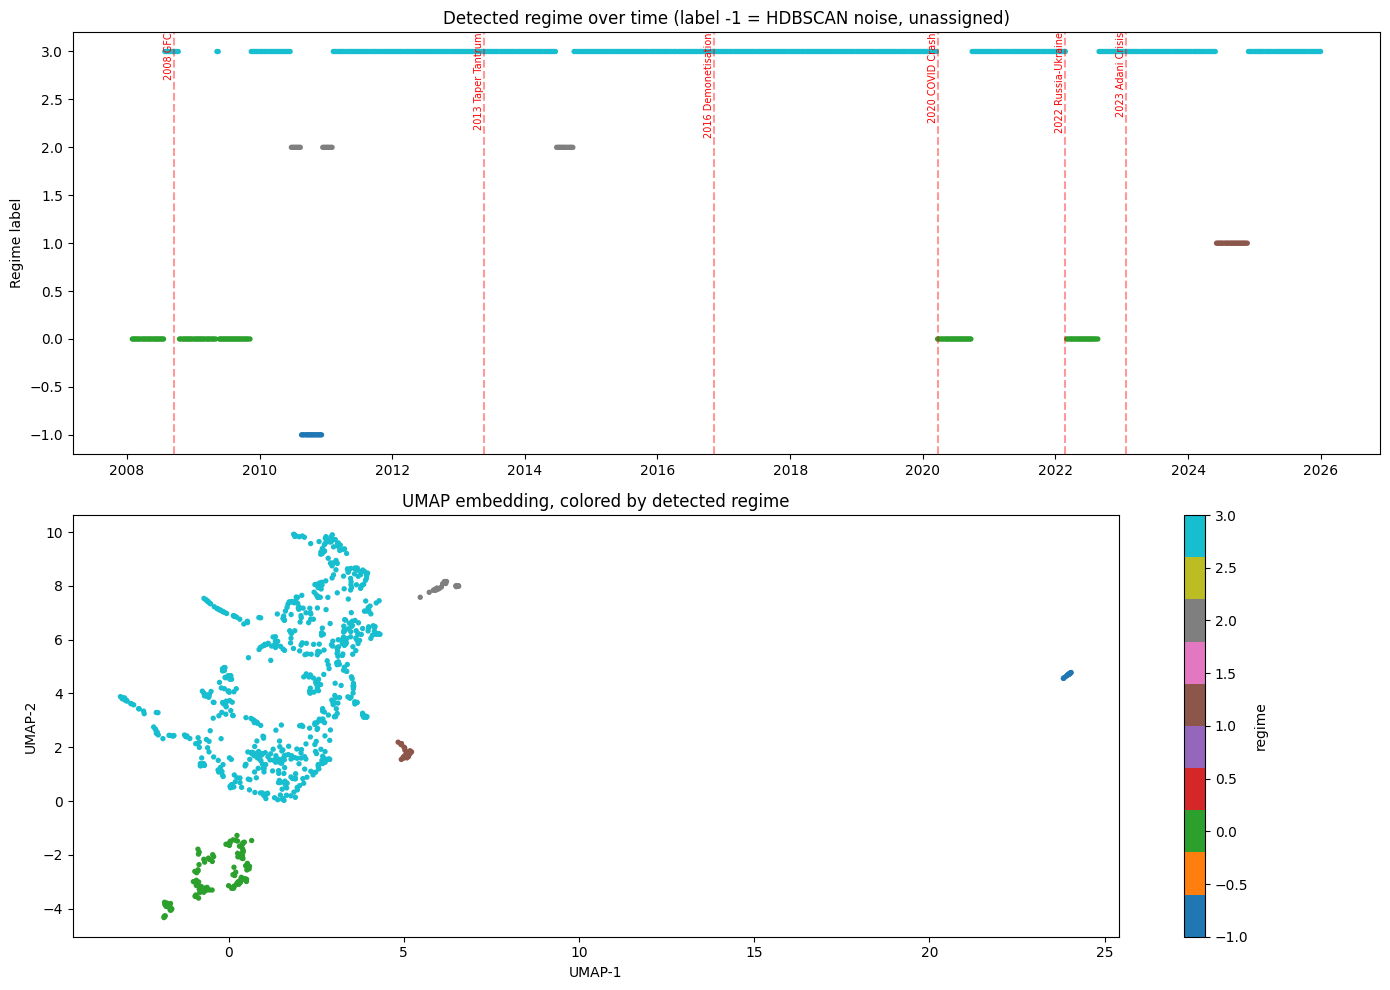

In [8]:
"""
Phase 3 -- Regime Detection and Labelling.

Input:  topo_features.csv  (from phase2_topology.py)
Output: regime_labels.csv       (rebal_date, umap_x, umap_y, [umap_z], regime)
        regime_validation.png   (regimes overlaid on Nifty price history + known events)
        regime_clustering_metrics.txt

    pip install umap-learn hdbscan scikit-learn --break-system-packages
    python phase3_regime_detection.py
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
import umap
import hdbscan

# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------
N_COMPONENTS = 2          # 2D embedding for viz; proposal allows 2D or 3D
UMAP_N_NEIGHBORS = 15     # umap default; lower = more local structure preserved
UMAP_MIN_DIST = 0.1
HDBSCAN_MIN_CLUSTER_SIZE = 20   # smallest group of rebalance dates to call a "regime"
RANDOM_STATE = 42

KNOWN_EVENTS = {
    "2008 GFC": "2008-09-15",
    "2013 Taper Tantrum": "2013-05-22",
    "2016 Demonetisation": "2016-11-08",
    "2020 COVID Crash": "2020-03-23",
    "2022 Russia-Ukraine": "2022-02-24",
    "2023 Adani Crisis": "2023-01-24",
}


def load_features(path: str = "topo_features.csv") -> pd.DataFrame:
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    df.index.name = "rebal_date"
    return df


def reduce_dimensionality(features: pd.DataFrame, n_components: int = N_COMPONENTS):
    """Standardize then UMAP. Scaling matters a lot here -- entropy scalars,
    Betti-curve bin counts, and landscape bin values live on very different
    numeric scales, and UMAP (like most distance-based methods) will let the
    largest-magnitude features dominate the embedding if you skip this."""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(features.values)

    reducer = umap.UMAP(
        n_components=n_components,
        n_neighbors=UMAP_N_NEIGHBORS,
        min_dist=UMAP_MIN_DIST,
        random_state=RANDOM_STATE,
    )
    embedding = reducer.fit_transform(X_scaled)
    return embedding, scaler, reducer


def cluster_regimes(embedding: np.ndarray, min_cluster_size: int = HDBSCAN_MIN_CLUSTER_SIZE):
    """HDBSCAN on the UMAP embedding, per the proposal's spec (cluster the
    *embedded* features, not the raw 1216-dim space -- HDBSCAN's density
    notion degrades in high dimensions, which is exactly why the proposal
    puts UMAP before it)."""
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, prediction_data=True)
    labels = clusterer.fit_predict(embedding)
    return labels, clusterer


def validate_clustering(embedding: np.ndarray, labels: np.ndarray) -> dict:
    """Silhouette + Davies-Bouldin, per the proposal's evaluation criteria.
    HDBSCAN's -1 (noise) points are excluded from both -- neither metric is
    defined for a 'non-cluster' label, and including them would corrupt
    the score."""
    mask = labels != -1
    n_clusters = len(set(labels[mask]))
    n_noise = int((labels == -1).sum())

    metrics = {"n_clusters": n_clusters, "n_noise_points": n_noise,
               "noise_fraction": n_noise / len(labels)}

    if n_clusters >= 2:
        metrics["silhouette_score"] = silhouette_score(embedding[mask], labels[mask])
        metrics["davies_bouldin_score"] = davies_bouldin_score(embedding[mask], labels[mask])
    else:
        metrics["silhouette_score"] = None
        metrics["davies_bouldin_score"] = None
        print("WARNING: fewer than 2 clusters found -- metrics undefined. "
              "Consider lowering HDBSCAN_MIN_CLUSTER_SIZE.")

    return metrics


def plot_validation(dates: pd.DatetimeIndex, embedding: np.ndarray, labels: np.ndarray,
                     out_path: str = "regime_validation.png"):
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # --- panel 1: regime label over time, with known events marked ---
    ax = axes[0]
    scatter = ax.scatter(dates, labels, c=labels, cmap="tab10", s=8)
    for name, d in KNOWN_EVENTS.items():
        ax.axvline(pd.Timestamp(d), color="red", linestyle="--", alpha=0.4)
        ax.text(pd.Timestamp(d), ax.get_ylim()[1], name, rotation=90,
                 fontsize=7, va="top", ha="right", color="red")
    ax.set_title("Detected regime over time (label -1 = HDBSCAN noise, unassigned)")
    ax.set_ylabel("Regime label")

    # --- panel 2: UMAP embedding, colored by regime ---
    ax2 = axes[1]
    sc = ax2.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap="tab10", s=8)
    ax2.set_title("UMAP embedding, colored by detected regime")
    ax2.set_xlabel("UMAP-1")
    ax2.set_ylabel("UMAP-2")
    plt.colorbar(sc, ax=ax2, label="regime")

    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    print(f"Saved {out_path}")


def main(features_path: str = "topo_features.csv"):
    print("Loading topological features...")
    features = load_features(features_path)
    print(f"  {features.shape[0]} dates x {features.shape[1]} features")

    print("\nReducing dimensionality (StandardScaler -> UMAP)...")
    embedding, scaler, reducer = reduce_dimensionality(features)
    print(f"  embedding shape: {embedding.shape}")

    print("\nClustering regimes (HDBSCAN on embedding)...")
    labels, clusterer = cluster_regimes(embedding)
    n_regimes = len(set(labels[labels != -1]))
    print(f"  found {n_regimes} regimes, "
          f"{(labels == -1).sum()} unassigned/noise dates out of {len(labels)}")

    print("\nValidating clustering quality...")
    metrics = validate_clustering(embedding, labels)
    for k, v in metrics.items():
        print(f"  {k}: {v}")

    # --- save labels ---
    out = pd.DataFrame({
        "umap_x": embedding[:, 0],
        "umap_y": embedding[:, 1],
        "regime": labels,
    }, index=features.index)
    out.to_csv("regime_labels.csv")
    print("\nSaved regime_labels.csv")

    # --- save metrics ---
    with open("regime_clustering_metrics.txt", "w") as f:
        for k, v in metrics.items():
            f.write(f"{k}: {v}\n")
        f.write("\nRegime sizes:\n")
        f.write(pd.Series(labels).value_counts().sort_index().to_string())
    print("Saved regime_clustering_metrics.txt")

    # --- plot ---
    plot_validation(features.index, embedding, labels)

    return out, metrics


if __name__ == "__main__":
    main()

In [9]:
"""
Phase 3 -- Regime Detection and Labelling.

Input:
    topo_features.csv
        884 dates x 1,216 topological features

Output:
    phase3_iterations/
        iteration_01/
            config.txt
            regime_labels.csv
            regime_clustering_metrics.txt
            regime_validation.png

        iteration_02/
            ...

        ...

        combined_iteration_metrics.csv
        combined_regime_labels.csv
        best_iteration.txt

The purpose of this version is to systematically test the Phase 3
configurations recommended by the analysis before proceeding to Phase 4.

Recommended experiments:
    - 3D UMAP
    - lower n_neighbors
    - lower min_dist
    - smaller HDBSCAN min_cluster_size
    - HDBSCAN min_samples
    - PCA before UMAP

    pip install umap-learn hdbscan scikit-learn --break-system-packages
    python phase3_regime_detection.py
"""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

import umap
import hdbscan


# ---------------------------------------------------------------------------
# Directory configuration
# ---------------------------------------------------------------------------

ITERATIONS_DIR = Path("phase3_iterations")

# All individual experiments are stored below this directory.
ITERATIONS_DIR.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------

RANDOM_STATE = 42

# PCA
USE_PCA = True
PCA_VARIANCE = 0.95

# ---------------------------------------------------------------------------
# Iterations to test
#
# The first iteration is the concrete configuration recommended by the
# Phase 3 analysis:
#
#   N_COMPONENTS = 3
#   UMAP_N_NEIGHBORS = 10
#   UMAP_MIN_DIST = 0.05
#   HDBSCAN_MIN_CLUSTER_SIZE = 10
#   min_samples = 5
#
# Additional iterations vary the parameters identified for tuning.
# ---------------------------------------------------------------------------

ITERATIONS = [

    {
        "name": "recommended_3d",
        "n_components": 3,
        "n_neighbors": 10,
        "min_dist": 0.05,
        "min_cluster_size": 10,
        "min_samples": 5,
    },

    {
        "name": "neighbors_15",
        "n_components": 3,
        "n_neighbors": 15,
        "min_dist": 0.05,
        "min_cluster_size": 10,
        "min_samples": 5,
    },

    {
        "name": "neighbors_20",
        "n_components": 3,
        "n_neighbors": 20,
        "min_dist": 0.05,
        "min_cluster_size": 10,
        "min_samples": 5,
    },

    {
        "name": "neighbors_30",
        "n_components": 3,
        "n_neighbors": 30,
        "min_dist": 0.05,
        "min_cluster_size": 10,
        "min_samples": 5,
    },

    {
        "name": "min_dist_0",
        "n_components": 3,
        "n_neighbors": 10,
        "min_dist": 0.0,
        "min_cluster_size": 10,
        "min_samples": 5,
    },

    {
        "name": "min_dist_01",
        "n_components": 3,
        "n_neighbors": 10,
        "min_dist": 0.1,
        "min_cluster_size": 10,
        "min_samples": 5,
    },

    {
        "name": "cluster_size_15",
        "n_components": 3,
        "n_neighbors": 10,
        "min_dist": 0.05,
        "min_cluster_size": 15,
        "min_samples": 5,
    },

    {
        "name": "cluster_size_20",
        "n_components": 3,
        "n_neighbors": 10,
        "min_dist": 0.05,
        "min_cluster_size": 20,
        "min_samples": 5,
    },

    {
        "name": "no_pca",
        "n_components": 3,
        "n_neighbors": 10,
        "min_dist": 0.05,
        "min_cluster_size": 10,
        "min_samples": 5,
    },

    {
        "name": "2d_comparison",
        "n_components": 2,
        "n_neighbors": 10,
        "min_dist": 0.05,
        "min_cluster_size": 10,
        "min_samples": 5,
    },

]


KNOWN_EVENTS = {
    "2008 GFC": "2008-09-15",
    "2013 Taper Tantrum": "2013-05-22",
    "2016 Demonetisation": "2016-11-08",
    "2020 COVID Crash": "2020-03-23",
    "2022 Russia-Ukraine": "2022-02-24",
    "2023 Adani Crisis": "2023-01-24",
}


# ---------------------------------------------------------------------------
# Loading
# ---------------------------------------------------------------------------

def load_features(path: str = "topo_features.csv") -> pd.DataFrame:
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    df.index.name = "rebal_date"
    return df


# ---------------------------------------------------------------------------
# Dimensionality reduction
# ---------------------------------------------------------------------------

def reduce_dimensionality(
    features: pd.DataFrame,
    n_components: int,
    n_neighbors: int,
    min_dist: float,
    use_pca: bool = USE_PCA,
):
    """
    StandardScaler -> optional PCA -> UMAP.

    PCA is applied after standardisation and before UMAP when enabled.
    """

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(features.values)

    pca = None

    if use_pca:
        pca = PCA(
            n_components=PCA_VARIANCE,
            random_state=RANDOM_STATE,
        )

        X_reduced = pca.fit_transform(X_scaled)

        print(
            f"  PCA: {X_scaled.shape[1]} -> "
            f"{X_reduced.shape[1]} components "
            f"({PCA_VARIANCE:.0%} variance)"
        )

    else:
        X_reduced = X_scaled
        print("  PCA: disabled")

    reducer = umap.UMAP(
        n_components=n_components,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        random_state=RANDOM_STATE,
    )

    embedding = reducer.fit_transform(X_reduced)

    return embedding, scaler, pca, reducer


# ---------------------------------------------------------------------------
# HDBSCAN clustering
# ---------------------------------------------------------------------------

def cluster_regimes(
    embedding: np.ndarray,
    min_cluster_size: int,
    min_samples: int,
):
    """
    HDBSCAN on the UMAP embedding.
    """

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        prediction_data=True,
    )

    labels = clusterer.fit_predict(embedding)

    return labels, clusterer


# ---------------------------------------------------------------------------
# Validation
# ---------------------------------------------------------------------------

def validate_clustering(
    embedding: np.ndarray,
    labels: np.ndarray,
) -> dict:
    """
    Calculate clustering metrics.

    HDBSCAN label -1 represents noise/unassigned observations and is
    excluded from silhouette and Davies-Bouldin calculations.
    """

    mask = labels != -1

    n_clusters = len(set(labels[mask]))
    n_noise = int((labels == -1).sum())

    metrics = {
        "n_clusters": n_clusters,
        "n_noise_points": n_noise,
        "noise_fraction": n_noise / len(labels),
    }

    if n_clusters >= 2:

        metrics["silhouette_score"] = silhouette_score(
            embedding[mask],
            labels[mask],
        )

        metrics["davies_bouldin_score"] = davies_bouldin_score(
            embedding[mask],
            labels[mask],
        )

    else:

        metrics["silhouette_score"] = None
        metrics["davies_bouldin_score"] = None

        print(
            "WARNING: fewer than 2 clusters found -- "
            "clustering metrics undefined."
        )

    return metrics


# ---------------------------------------------------------------------------
# Plot validation
# ---------------------------------------------------------------------------

def plot_validation(
    dates: pd.DatetimeIndex,
    embedding: np.ndarray,
    labels: np.ndarray,
    out_path: str,
):
    """
    Validation plot.

    Panel 1:
        Regime labels over time.

    Panel 2:
        UMAP embedding.

    For 3D UMAP, only the first two coordinates are plotted because
    the validation figure remains a 2D visualization.
    """

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(14, 10),
    )

    # -----------------------------------------------------------------------
    # Panel 1: regimes over time
    # -----------------------------------------------------------------------

    ax = axes[0]

    scatter = ax.scatter(
        dates,
        labels,
        c=labels,
        cmap="tab10",
        s=8,
    )

    for name, d in KNOWN_EVENTS.items():

        ax.axvline(
            pd.Timestamp(d),
            color="red",
            linestyle="--",
            alpha=0.4,
        )

        ax.text(
            pd.Timestamp(d),
            ax.get_ylim()[1],
            name,
            rotation=90,
            fontsize=7,
            va="top",
            ha="right",
            color="red",
        )

    ax.set_title(
        "Detected regime over time "
        "(label -1 = HDBSCAN noise, unassigned)"
    )

    ax.set_ylabel("Regime label")

    # -----------------------------------------------------------------------
    # Panel 2: UMAP embedding
    # -----------------------------------------------------------------------

    ax2 = axes[1]

    sc = ax2.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=labels,
        cmap="tab10",
        s=8,
    )

    ax2.set_title(
        "UMAP embedding, colored by detected regime"
    )

    ax2.set_xlabel("UMAP-1")
    ax2.set_ylabel("UMAP-2")

    plt.colorbar(
        sc,
        ax=ax2,
        label="regime",
    )

    plt.tight_layout()

    plt.savefig(
        out_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.close()

    print(f"Saved {out_path}")


# ---------------------------------------------------------------------------
# Save iteration configuration
# ---------------------------------------------------------------------------

def save_config(
    iteration_dir: Path,
    config: dict,
    features: pd.DataFrame,
):
    """
    Save all parameters associated with one experiment.
    """

    with open(iteration_dir / "config.txt", "w") as f:

        f.write("PHASE 3 ITERATION CONFIGURATION\n")
        f.write("=" * 60 + "\n\n")

        f.write(f"Input observations : {features.shape[0]}\n")
        f.write(f"Input features     : {features.shape[1]}\n\n")

        f.write(f"PCA enabled        : {USE_PCA}\n")

        if USE_PCA:
            f.write(f"PCA variance       : {PCA_VARIANCE}\n")

        f.write("\nUMAP / HDBSCAN parameters\n")
        f.write("-" * 60 + "\n")

        for key, value in config.items():
            f.write(f"{key}: {value}\n")


# ---------------------------------------------------------------------------
# Run one iteration
# ---------------------------------------------------------------------------

def run_iteration(
    iteration_number: int,
    config: dict,
    features: pd.DataFrame,
):
    """
    Execute and save one complete Phase 3 experiment.
    """

    iteration_name = (
        f"iteration_{iteration_number:02d}_{config['name']}"
    )

    iteration_dir = ITERATIONS_DIR / iteration_name
    iteration_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    print("\n" + "=" * 70)
    print(f"ITERATION {iteration_number}: {config['name']}")
    print("=" * 70)

    save_config(
        iteration_dir,
        config,
        features,
    )

    # -----------------------------------------------------------------------
    # UMAP
    # -----------------------------------------------------------------------

    print("\nReducing dimensionality...")

    embedding, scaler, pca, reducer = reduce_dimensionality(
        features,
        n_components=config["n_components"],
        n_neighbors=config["n_neighbors"],
        min_dist=config["min_dist"],
        use_pca=(
            False
            if config["name"] == "no_pca"
            else USE_PCA
        ),
    )

    print(f"  embedding shape: {embedding.shape}")

    # -----------------------------------------------------------------------
    # HDBSCAN
    # -----------------------------------------------------------------------

    print("\nClustering regimes...")

    labels, clusterer = cluster_regimes(
        embedding,
        min_cluster_size=config["min_cluster_size"],
        min_samples=config["min_samples"],
    )

    n_regimes = len(
        set(labels[labels != -1])
    )

    n_noise = int(
        (labels == -1).sum()
    )

    print(
        f"  found {n_regimes} regimes, "
        f"{n_noise} unassigned/noise dates "
        f"out of {len(labels)}"
    )

    # -----------------------------------------------------------------------
    # Validation
    # -----------------------------------------------------------------------

    print("\nValidating clustering quality...")

    metrics = validate_clustering(
        embedding,
        labels,
    )

    for key, value in metrics.items():
        print(f"  {key}: {value}")

    # -----------------------------------------------------------------------
    # Save regime labels
    # -----------------------------------------------------------------------

    out = pd.DataFrame(
        {
            "umap_x": embedding[:, 0],
            "umap_y": embedding[:, 1],
            "regime": labels,
        },
        index=features.index,
    )

    # Save UMAP-3 if this is a 3D embedding.
    if embedding.shape[1] >= 3:
        out["umap_z"] = embedding[:, 2]

    out.index.name = "rebal_date"

    labels_path = iteration_dir / "regime_labels.csv"

    out.to_csv(labels_path)

    print(f"Saved {labels_path}")

    # -----------------------------------------------------------------------
    # Save metrics
    # -----------------------------------------------------------------------

    metrics["iteration"] = iteration_number
    metrics["iteration_name"] = config["name"]

    metrics["n_components"] = config["n_components"]
    metrics["n_neighbors"] = config["n_neighbors"]
    metrics["min_dist"] = config["min_dist"]
    metrics["min_cluster_size"] = config["min_cluster_size"]
    metrics["min_samples"] = config["min_samples"]

    iteration_metrics_path = (
        iteration_dir /
        "regime_clustering_metrics.txt"
    )

    with open(iteration_metrics_path, "w") as f:

        f.write("PHASE 3 CLUSTERING METRICS\n")
        f.write("=" * 60 + "\n\n")

        for key, value in metrics.items():
            f.write(f"{key}: {value}\n")

        f.write("\nRegime sizes:\n")

        regime_sizes = (
            pd.Series(labels)
            .value_counts()
            .sort_index()
        )

        f.write(
            regime_sizes.to_string()
        )

    print(
        f"Saved {iteration_metrics_path}"
    )

    # -----------------------------------------------------------------------
    # Plot
    # -----------------------------------------------------------------------

    plot_path = (
        iteration_dir /
        "regime_validation.png"
    )

    plot_validation(
        features.index,
        embedding,
        labels,
        str(plot_path),
    )

    return {
        "metrics": metrics,
        "labels": out,
        "iteration_name": iteration_name,
    }


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

def main(
    features_path: str = "topo_features.csv",
):
    print("=" * 70)
    print("PHASE 3 -- REGIME DETECTION")
    print("=" * 70)

    # -----------------------------------------------------------------------
    # Load features
    # -----------------------------------------------------------------------

    print("\nLoading topological features...")

    features = load_features(
        features_path
    )

    print(
        f"  {features.shape[0]} dates x "
        f"{features.shape[1]} features"
    )

    # -----------------------------------------------------------------------
    # Run all iterations
    # -----------------------------------------------------------------------

    all_metrics = []
    all_labels = []

    for i, config in enumerate(
        ITERATIONS,
        start=1,
    ):

        result = run_iteration(
            i,
            config,
            features,
        )

        all_metrics.append(
            result["metrics"]
        )

        # Rename regime column so that results from different iterations
        # can coexist in one combined table.
        labels = result["labels"].copy()

        labels = labels.rename(
            columns={
                "umap_x":
                    f"iter_{i:02d}_umap_x",

                "umap_y":
                    f"iter_{i:02d}_umap_y",

                "umap_z":
                    f"iter_{i:02d}_umap_z",

                "regime":
                    f"iter_{i:02d}_regime",
            }
        )

        all_labels.append(
            labels
        )

    # -----------------------------------------------------------------------
    # Combine metrics from every iteration
    # -----------------------------------------------------------------------

    metrics_df = pd.DataFrame(
        all_metrics
    )

    # Put important comparison columns first.
    preferred_columns = [
        "iteration",
        "iteration_name",
        "n_components",
        "n_neighbors",
        "min_dist",
        "min_cluster_size",
        "min_samples",
        "n_clusters",
        "n_noise_points",
        "noise_fraction",
        "silhouette_score",
        "davies_bouldin_score",
    ]

    metrics_df = metrics_df[
        [
            c
            for c in preferred_columns
            if c in metrics_df.columns
        ]
    ]

    metrics_path = (
        ITERATIONS_DIR /
        "combined_iteration_metrics.csv"
    )

    metrics_df.to_csv(
        metrics_path,
        index=False,
    )

    print(
        f"\nSaved combined metrics: "
        f"{metrics_path}"
    )

    # -----------------------------------------------------------------------
    # Combine regime labels from every iteration
    # -----------------------------------------------------------------------

    combined_labels = pd.concat(
        all_labels,
        axis=1,
    )

    combined_labels.index.name = "rebal_date"

    labels_path = (
        ITERATIONS_DIR /
        "combined_regime_labels.csv"
    )

    combined_labels.to_csv(
        labels_path
    )

    print(
        f"Saved combined regime labels: "
        f"{labels_path}"
    )

    # -----------------------------------------------------------------------
    # Identify best iteration by silhouette score
    # -----------------------------------------------------------------------

    valid_metrics = metrics_df.dropna(
        subset=["silhouette_score"]
    )

    if len(valid_metrics) > 0:

        best_row = valid_metrics.loc[
            valid_metrics["silhouette_score"].idxmax()
        ]

        best_iteration = int(
            best_row["iteration"]
        )

        best_name = best_row[
            "iteration_name"
        ]

        best_silhouette = best_row[
            "silhouette_score"
        ]

        best_path = (
            ITERATIONS_DIR /
            "best_iteration.txt"
        )

        with open(best_path, "w") as f:

            f.write(
                "BEST PHASE 3 ITERATION\n"
            )
            f.write(
                "=" * 60 + "\n\n"
            )

            f.write(
                f"Iteration       : "
                f"{best_iteration}\n"
            )

            f.write(
                f"Name            : "
                f"{best_name}\n"
            )

            f.write(
                f"Silhouette      : "
                f"{best_silhouette}\n"
            )

            f.write(
                f"Clusters        : "
                f"{best_row['n_clusters']}\n"
            )

            f.write(
                f"Noise points    : "
                f"{best_row['n_noise_points']}\n"
            )

            f.write(
                f"Noise fraction  : "
                f"{best_row['noise_fraction']}\n"
            )

            f.write(
                f"Davies-Bouldin  : "
                f"{best_row['davies_bouldin_score']}\n"
            )

        print(
            "\nBest iteration according to "
            f"silhouette score: "
            f"{best_iteration} ({best_name})"
        )

        print(
            f"  silhouette = "
            f"{best_silhouette:.4f}"
        )

        print(
            f"Saved {best_path}"
        )

    # -----------------------------------------------------------------------
    # Final comparison table
    # -----------------------------------------------------------------------

    print("\n" + "=" * 70)
    print("ITERATION COMPARISON")
    print("=" * 70)

    print(
        metrics_df[
            [
                "iteration",
                "iteration_name",
                "n_clusters",
                "n_noise_points",
                "noise_fraction",
                "silhouette_score",
                "davies_bouldin_score",
            ]
        ].to_string(index=False)
    )

    print("\nPhase 3 iteration analysis complete.")
    print(
        f"All results stored in: "
        f"{ITERATIONS_DIR}/"
    )

    return metrics_df, combined_labels


# ---------------------------------------------------------------------------
# Entry point
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    main()

PHASE 3 -- REGIME DETECTION

Loading topological features...
  884 dates x 1216 features

ITERATION 1: recommended_3d

Reducing dimensionality...
  PCA: 1216 -> 113 components (95% variance)


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  embedding shape: (884, 3)

Clustering regimes...
  found 34 regimes, 97 unassigned/noise dates out of 884

Validating clustering quality...
  n_clusters: 34
  n_noise_points: 97
  noise_fraction: 0.10972850678733032
  silhouette_score: 0.5971148610115051
  davies_bouldin_score: 0.5496829630044682
Saved phase3_iterations/iteration_01_recommended_3d/regime_labels.csv
Saved phase3_iterations/iteration_01_recommended_3d/regime_clustering_metrics.txt
Saved phase3_iterations/iteration_01_recommended_3d/regime_validation.png

ITERATION 2: neighbors_15

Reducing dimensionality...
  PCA: 1216 -> 113 components (95% variance)


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  embedding shape: (884, 3)

Clustering regimes...
  found 33 regimes, 134 unassigned/noise dates out of 884

Validating clustering quality...
  n_clusters: 33
  n_noise_points: 134
  noise_fraction: 0.1515837104072398
  silhouette_score: 0.5789085626602173
  davies_bouldin_score: 0.557554839470573
Saved phase3_iterations/iteration_02_neighbors_15/regime_labels.csv
Saved phase3_iterations/iteration_02_neighbors_15/regime_clustering_metrics.txt
Saved phase3_iterations/iteration_02_neighbors_15/regime_validation.png

ITERATION 3: neighbors_20

Reducing dimensionality...
  PCA: 1216 -> 113 components (95% variance)


...

  embedding shape: (884, 3)

Clustering regimes...
  found 22 regimes, 143 unassigned/noise dates out of 884

Validating clustering quality...
  n_clusters: 22
  n_noise_points: 143
  noise_fraction: 0.16176470588235295
  silhouette_score: 0.5779345631599426
  davies_bouldin_score: 0.5379033399842782
Saved phase3_iterations/iteration_08_cluster_size_20/regime_labels.csv
Saved phase3_iterations/iteration_08_cluster_size_20/regime_clustering_metrics.txt
Saved phase3_iterations/iteration_08_cluster_size_20/regime_validation.png

ITERATION 9: no_pca

Reducing dimensionality...
  PCA: disabled


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  embedding shape: (884, 3)

Clustering regimes...
  found 31 regimes, 133 unassigned/noise dates out of 884

Validating clustering quality...
  n_clusters: 31
  n_noise_points: 133
  noise_fraction: 0.1504524886877828
  silhouette_score: 0.592445969581604
  davies_bouldin_score: 0.5244061651825892
Saved phase3_iterations/iteration_09_no_pca/regime_labels.csv
Saved phase3_iterations/iteration_09_no_pca/regime_clustering_metrics.txt
Saved phase3_iterations/iteration_09_no_pca/regime_validation.png

ITERATION 10: 2d_comparison

Reducing dimensionality...
  PCA: 1216 -> 113 components (95% variance)


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  embedding shape: (884, 2)

Clustering regimes...
  found 32 regimes, 102 unassigned/noise dates out of 884

Validating clustering quality...
  n_clusters: 32
  n_noise_points: 102
  noise_fraction: 0.11538461538461539
  silhouette_score: 0.6125727891921997
  davies_bouldin_score: 0.4925707856814386
Saved phase3_iterations/iteration_10_2d_comparison/regime_labels.csv
Saved phase3_iterations/iteration_10_2d_comparison/regime_clustering_metrics.txt
Saved phase3_iterations/iteration_10_2d_comparison/regime_validation.png

Saved combined metrics: phase3_iterations/combined_iteration_metrics.csv
Saved combined regime labels: phase3_iterations/combined_regime_labels.csv

Best iteration according to silhouette score: 10 (2d_comparison)
  silhouette = 0.6126
Saved phase3_iterations/best_iteration.txt

ITERATION COMPARISON
 iteration  iteration_name  n_clusters  n_noise_points  noise_fraction  silhouette_score  davies_bouldin_score
         1  recommended_3d          34              97        

In [12]:
"""
Phase 3 -- Round 2: Regime Detection and Labelling.

Round 2 is based strictly on the analysis of Round 1.

Fixed embedding:
    StandardScaler -> PCA(95% variance) -> UMAP 2D
    n_neighbors = 10
    min_dist = 0.0
    random_state = 42

HDBSCAN sweep:
    min_cluster_size = [50, 75, 100, 125, 150, 175, 200]
    min_samples = 5

K-Means baseline:
    K = [4, 5, 6]

Input:
    topo_features.csv

Output:
    phase3_round2_iterations/
        ├── mcs_050/
        ├── mcs_075/
        ├── mcs_100/
        ├── mcs_125/
        ├── mcs_150/
        ├── mcs_175/
        ├── mcs_200/
        ├── kmeans_04/
        ├── kmeans_05/
        ├── kmeans_06/
        ├── combined_iteration_metrics.csv
        ├── combined_regime_labels.csv
        ├── best_hdbscan_iteration.txt
        └── round2_summary.txt

    pip install umap-learn hdbscan scikit-learn --break-system-packages
    python phase3_regime_detection_round2.py
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

import umap
import hdbscan


# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------

# Fixed embedding from Round 1 analysis
N_COMPONENTS = 2
PCA_VARIANCE = 0.95
UMAP_N_NEIGHBORS = 10
UMAP_MIN_DIST = 0.0
RANDOM_STATE = 42

# HDBSCAN Round 2 sweep
HDBSCAN_MIN_CLUSTER_SIZES = [50, 75, 100, 125, 150, 175, 200]
HDBSCAN_MIN_SAMPLES = 5

# K-Means baseline
KMEANS_K_VALUES = [4, 5, 6]

# Output directory
OUTPUT_DIR = "phase3_round2_iterations"


KNOWN_EVENTS = {
    "2008 GFC": "2008-09-15",
    "2013 Taper Tantrum": "2013-05-22",
    "2016 Demonetisation": "2016-11-08",
    "2020 COVID Crash": "2020-03-23",
    "2022 Russia-Ukraine": "2022-02-24",
    "2023 Adani Crisis": "2023-01-24",
}


# ---------------------------------------------------------------------------
# Loading
# ---------------------------------------------------------------------------

def load_features(path: str = "topo_features.csv") -> pd.DataFrame:
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    df.index.name = "rebal_date"
    return df


# ---------------------------------------------------------------------------
# Dimensionality reduction
# ---------------------------------------------------------------------------

def reduce_dimensionality(
    features: pd.DataFrame,
    n_components: int = N_COMPONENTS
):
    """
    StandardScaler -> PCA(95% variance) -> UMAP.

    This is the fixed embedding configuration selected from Round 1:
        PCA retaining 95% variance
        UMAP 2D
        n_neighbors = 10
        min_dist = 0.0
        random_state = 42
    """

    # ---------------------------------------------------------------
    # Step 1: Standardization
    # ---------------------------------------------------------------
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(features.values)

    print(f"  Standardized feature matrix: {X_scaled.shape}")

    # ---------------------------------------------------------------
    # Step 2: PCA retaining 95% variance
    # ---------------------------------------------------------------
    pca = PCA(
        n_components=PCA_VARIANCE,
        random_state=RANDOM_STATE
    )

    X_pca = pca.fit_transform(X_scaled)

    explained = pca.explained_variance_ratio_.sum()

    print(
        f"  PCA dimensions: {X_pca.shape[1]} "
        f"(explained variance: {explained:.4f})"
    )

    # ---------------------------------------------------------------
    # Step 3: UMAP
    # ---------------------------------------------------------------
    reducer = umap.UMAP(
        n_components=n_components,
        n_neighbors=UMAP_N_NEIGHBORS,
        min_dist=UMAP_MIN_DIST,
        random_state=RANDOM_STATE,
    )

    embedding = reducer.fit_transform(X_pca)

    print(f"  UMAP embedding shape: {embedding.shape}")

    return embedding, scaler, pca, reducer


# ---------------------------------------------------------------------------
# HDBSCAN clustering
# ---------------------------------------------------------------------------

def cluster_regimes(
    embedding: np.ndarray,
    min_cluster_size: int,
    min_samples: int = HDBSCAN_MIN_SAMPLES
):
    """
    HDBSCAN on the fixed 2D UMAP embedding.

    Only min_cluster_size changes between Round 2 iterations.
    """

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        prediction_data=True
    )

    labels = clusterer.fit_predict(embedding)

    return labels, clusterer


# ---------------------------------------------------------------------------
# K-Means clustering
# ---------------------------------------------------------------------------

def cluster_kmeans(
    embedding: np.ndarray,
    n_clusters: int
):
    """
    K-Means baseline on the same fixed UMAP embedding.
    """

    clusterer = KMeans(
        n_clusters=n_clusters,
        random_state=RANDOM_STATE,
        n_init=20
    )

    labels = clusterer.fit_predict(embedding)

    return labels, clusterer


# ---------------------------------------------------------------------------
# Validation
# ---------------------------------------------------------------------------

def validate_clustering(
    embedding: np.ndarray,
    labels: np.ndarray,
    exclude_noise: bool = True
) -> dict:
    """
    Calculate clustering diagnostics.

    HDBSCAN:
        label -1 = noise and is excluded from clustering metrics.

    K-Means:
        there is no noise label, so all observations are included.
    """

    if exclude_noise:
        mask = labels != -1
    else:
        mask = np.ones(len(labels), dtype=bool)

    valid_labels = labels[mask]
    valid_embedding = embedding[mask]

    unique_clusters = sorted(set(valid_labels))
    n_clusters = len(unique_clusters)

    n_noise = int((labels == -1).sum()) if exclude_noise else 0

    metrics = {
        "n_clusters": n_clusters,
        "n_noise_points": n_noise,
        "noise_fraction": n_noise / len(labels),
    }

    # ---------------------------------------------------------------
    # Cluster sizes
    # ---------------------------------------------------------------

    cluster_sizes = pd.Series(valid_labels).value_counts().sort_index()

    if len(cluster_sizes) > 0:
        metrics["min_cluster_size_observed"] = int(cluster_sizes.min())
        metrics["max_cluster_size_observed"] = int(cluster_sizes.max())
        metrics["mean_cluster_size"] = float(cluster_sizes.mean())
    else:
        metrics["min_cluster_size_observed"] = 0
        metrics["max_cluster_size_observed"] = 0
        metrics["mean_cluster_size"] = 0.0

    # ---------------------------------------------------------------
    # Silhouette + Davies-Bouldin
    # ---------------------------------------------------------------

    if n_clusters >= 2:

        metrics["silhouette_score"] = silhouette_score(
            valid_embedding,
            valid_labels
        )

        metrics["davies_bouldin_score"] = davies_bouldin_score(
            valid_embedding,
            valid_labels
        )

    else:

        metrics["silhouette_score"] = np.nan
        metrics["davies_bouldin_score"] = np.nan

    return metrics


# ---------------------------------------------------------------------------
# Target evaluation
# ---------------------------------------------------------------------------

def evaluate_target(metrics: dict) -> dict:
    """
    Apply the exact Round 2 target supplied in the analysis:

        4-6 clusters
        silhouette > 0.30
        every cluster >= 100 observations
        noise fraction < 15%
    """

    cluster_ok = 4 <= metrics["n_clusters"] <= 6

    silhouette_ok = (
        pd.notna(metrics["silhouette_score"])
        and metrics["silhouette_score"] > 0.30
    )

    min_size_ok = (
        metrics["min_cluster_size_observed"] >= 100
    )

    noise_ok = (
        metrics["noise_fraction"] < 0.15
    )

    metrics["target_4_to_6_clusters"] = cluster_ok
    metrics["target_silhouette_gt_030"] = silhouette_ok
    metrics["target_min_cluster_size_ge_100"] = min_size_ok
    metrics["target_noise_lt_15pct"] = noise_ok

    metrics["meets_all_targets"] = (
        cluster_ok
        and silhouette_ok
        and min_size_ok
        and noise_ok
    )

    return metrics


# ---------------------------------------------------------------------------
# Plot validation
# ---------------------------------------------------------------------------

def plot_validation(
    dates: pd.DatetimeIndex,
    embedding: np.ndarray,
    labels: np.ndarray,
    out_path: str
):
    """
    Two-panel validation plot:

        Panel 1:
            regime labels over time

        Panel 2:
            UMAP embedding coloured by regime
    """

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(14, 10)
    )

    # ---------------------------------------------------------------
    # Panel 1: regimes through time
    # ---------------------------------------------------------------

    ax = axes[0]

    ax.scatter(
        dates,
        labels,
        c=labels,
        cmap="tab10",
        s=8
    )

    for name, d in KNOWN_EVENTS.items():

        ax.axvline(
            pd.Timestamp(d),
            color="red",
            linestyle="--",
            alpha=0.4
        )

        ax.text(
            pd.Timestamp(d),
            ax.get_ylim()[1],
            name,
            rotation=90,
            fontsize=7,
            va="top",
            ha="right",
            color="red"
        )

    ax.set_title(
        "Detected regime over time "
        "(label -1 = HDBSCAN noise, unassigned)"
    )

    ax.set_ylabel("Regime label")

    # ---------------------------------------------------------------
    # Panel 2: UMAP
    # ---------------------------------------------------------------

    ax2 = axes[1]

    sc = ax2.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=labels,
        cmap="tab10",
        s=8
    )

    ax2.set_title(
        "UMAP embedding, coloured by detected regime"
    )

    ax2.set_xlabel("UMAP-1")
    ax2.set_ylabel("UMAP-2")

    plt.colorbar(
        sc,
        ax=ax2,
        label="regime"
    )

    plt.tight_layout()

    plt.savefig(
        out_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.close()

    print(f"  Saved {out_path}")


# ---------------------------------------------------------------------------
# Save iteration
# ---------------------------------------------------------------------------

def save_iteration(
    name: str,
    dates: pd.DatetimeIndex,
    embedding: np.ndarray,
    labels: np.ndarray,
    metrics: dict
):
    """
    Save everything belonging to one iteration into its own directory.
    """

    iteration_dir = os.path.join(
        OUTPUT_DIR,
        name
    )

    os.makedirs(
        iteration_dir,
        exist_ok=True
    )

    # ---------------------------------------------------------------
    # Labels
    # ---------------------------------------------------------------

    out = pd.DataFrame(
        {
            "umap_x": embedding[:, 0],
            "umap_y": embedding[:, 1],
            "regime": labels,
        },
        index=dates
    )

    out.index.name = "rebal_date"

    out.to_csv(
        os.path.join(
            iteration_dir,
            "regime_labels.csv"
        )
    )

    # ---------------------------------------------------------------
    # Metrics
    # ---------------------------------------------------------------

    with open(
        os.path.join(
            iteration_dir,
            "metrics.txt"
        ),
        "w"
    ) as f:

        for k, v in metrics.items():
            f.write(f"{k}: {v}\n")

        f.write("\nRegime sizes:\n")

        f.write(
            pd.Series(labels)
            .value_counts()
            .sort_index()
            .to_string()
        )

    # ---------------------------------------------------------------
    # Plot
    # ---------------------------------------------------------------

    plot_validation(
        dates,
        embedding,
        labels,
        os.path.join(
            iteration_dir,
            "regime_validation.png"
        )
    )

    return out


# ---------------------------------------------------------------------------
# Main Round 2
# ---------------------------------------------------------------------------

def main(
    features_path: str = "topo_features.csv"
):

    # ---------------------------------------------------------------
    # Create output directory
    # ---------------------------------------------------------------

    os.makedirs(
        OUTPUT_DIR,
        exist_ok=True
    )

    # ---------------------------------------------------------------
    # Load Phase 2 features
    # ---------------------------------------------------------------

    print("=" * 70)
    print("PHASE 3 -- ROUND 2")
    print("=" * 70)

    print("\nLoading topological features...")

    features = load_features(
        features_path
    )

    print(
        f"  {features.shape[0]} dates x "
        f"{features.shape[1]} features"
    )

    # ---------------------------------------------------------------
    # Fixed embedding
    # ---------------------------------------------------------------

    print(
        "\nReducing dimensionality "
        "(StandardScaler -> PCA(95%) -> UMAP)..."
    )

    embedding, scaler, pca, reducer = reduce_dimensionality(
        features
    )

    # ---------------------------------------------------------------
    # Save embedding once
    # ---------------------------------------------------------------

    embedding_df = pd.DataFrame(
        {
            "rebal_date": features.index,
            "umap_x": embedding[:, 0],
            "umap_y": embedding[:, 1],
        }
    )

    embedding_df.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "fixed_umap_embedding.csv"
        ),
        index=False
    )

    # ---------------------------------------------------------------
    # Store all results
    # ---------------------------------------------------------------

    all_metrics = []
    all_labels = []

    # ===============================================================
    # HDBSCAN SWEEP
    # ===============================================================

    print("\n" + "=" * 70)
    print("HDBSCAN MIN_CLUSTER_SIZE SWEEP")
    print("=" * 70)

    for min_cluster_size in HDBSCAN_MIN_CLUSTER_SIZES:

        name = f"mcs_{min_cluster_size:03d}"

        print(
            f"\n--- {name} ---"
        )

        print(
            f"min_cluster_size = {min_cluster_size}"
        )

        print(
            f"min_samples = {HDBSCAN_MIN_SAMPLES}"
        )

        # -----------------------------------------------------------
        # Cluster
        # -----------------------------------------------------------

        labels, clusterer = cluster_regimes(
            embedding,
            min_cluster_size=min_cluster_size,
            min_samples=HDBSCAN_MIN_SAMPLES
        )

        # -----------------------------------------------------------
        # Validate
        # -----------------------------------------------------------

        metrics = validate_clustering(
            embedding,
            labels,
            exclude_noise=True
        )

        metrics = evaluate_target(
            metrics
        )

        # Add iteration metadata
        metrics["method"] = "HDBSCAN"
        metrics["iteration"] = name
        metrics["min_cluster_size_parameter"] = min_cluster_size
        metrics["min_samples_parameter"] = HDBSCAN_MIN_SAMPLES
        metrics["n_components"] = N_COMPONENTS
        metrics["pca_variance"] = PCA_VARIANCE
        metrics["umap_n_neighbors"] = UMAP_N_NEIGHBORS
        metrics["umap_min_dist"] = UMAP_MIN_DIST

        # -----------------------------------------------------------
        # Print
        # -----------------------------------------------------------

        print(
            f"clusters             : {metrics['n_clusters']}"
        )

        print(
            f"noise points         : {metrics['n_noise_points']}"
        )

        print(
            f"noise fraction       : "
            f"{metrics['noise_fraction']:.4f}"
        )

        print(
            f"min observed cluster : "
            f"{metrics['min_cluster_size_observed']}"
        )

        print(
            f"silhouette           : "
            f"{metrics['silhouette_score']}"
        )

        print(
            f"Davies-Bouldin       : "
            f"{metrics['davies_bouldin_score']}"
        )

        print(
            f"MEETS ALL TARGETS    : "
            f"{metrics['meets_all_targets']}"
        )

        # -----------------------------------------------------------
        # Save iteration
        # -----------------------------------------------------------

        labels_df = save_iteration(
            name,
            features.index,
            embedding,
            labels,
            metrics
        )

        all_metrics.append(metrics)

        labels_df = labels_df.copy()
        labels_df["method"] = "HDBSCAN"
        labels_df["iteration"] = name

        all_labels.append(
            labels_df.reset_index()
        )

    # ===============================================================
    # K-MEANS BASELINE
    # ===============================================================

    print("\n" + "=" * 70)
    print("K-MEANS BASELINE")
    print("=" * 70)

    for k in KMEANS_K_VALUES:

        name = f"kmeans_{k:02d}"

        print(
            f"\n--- {name} ---"
        )

        print(
            f"K = {k}"
        )

        # -----------------------------------------------------------
        # Cluster
        # -----------------------------------------------------------

        labels, clusterer = cluster_kmeans(
            embedding,
            n_clusters=k
        )

        # -----------------------------------------------------------
        # Validate
        # -----------------------------------------------------------

        metrics = validate_clustering(
            embedding,
            labels,
            exclude_noise=False
        )

        metrics = evaluate_target(
            metrics
        )

        metrics["method"] = "KMeans"
        metrics["iteration"] = name
        metrics["k"] = k
        metrics["min_cluster_size_parameter"] = np.nan
        metrics["min_samples_parameter"] = np.nan
        metrics["n_components"] = N_COMPONENTS
        metrics["pca_variance"] = PCA_VARIANCE
        metrics["umap_n_neighbors"] = UMAP_N_NEIGHBORS
        metrics["umap_min_dist"] = UMAP_MIN_DIST

        # -----------------------------------------------------------
        # Print
        # -----------------------------------------------------------

        print(
            f"clusters             : {metrics['n_clusters']}"
        )

        print(
            f"noise fraction       : "
            f"{metrics['noise_fraction']:.4f}"
        )

        print(
            f"min observed cluster : "
            f"{metrics['min_cluster_size_observed']}"
        )

        print(
            f"silhouette           : "
            f"{metrics['silhouette_score']}"
        )

        print(
            f"Davies-Bouldin       : "
            f"{metrics['davies_bouldin_score']}"
        )

        # -----------------------------------------------------------
        # Save iteration
        # -----------------------------------------------------------

        labels_df = save_iteration(
            name,
            features.index,
            embedding,
            labels,
            metrics
        )

        all_metrics.append(metrics)

        labels_df = labels_df.copy()
        labels_df["method"] = "KMeans"
        labels_df["iteration"] = name

        all_labels.append(
            labels_df.reset_index()
        )

    # ===============================================================
    # COMBINE RESULTS
    # ===============================================================

    print("\n" + "=" * 70)
    print("COMBINING RESULTS")
    print("=" * 70)

    metrics_df = pd.DataFrame(
        all_metrics
    )

    # Put the most important columns first
    preferred_columns = [
        "method",
        "iteration",
        "n_clusters",
        "n_noise_points",
        "noise_fraction",
        "min_cluster_size_observed",
        "max_cluster_size_observed",
        "mean_cluster_size",
        "silhouette_score",
        "davies_bouldin_score",
        "target_4_to_6_clusters",
        "target_silhouette_gt_030",
        "target_min_cluster_size_ge_100",
        "target_noise_lt_15pct",
        "meets_all_targets",
        "min_cluster_size_parameter",
        "min_samples_parameter",
        "k",
        "n_components",
        "pca_variance",
        "umap_n_neighbors",
        "umap_min_dist",
    ]

    preferred_columns = [
        c for c in preferred_columns
        if c in metrics_df.columns
    ]

    remaining_columns = [
        c for c in metrics_df.columns
        if c not in preferred_columns
    ]

    metrics_df = metrics_df[
        preferred_columns + remaining_columns
    ]

    metrics_path = os.path.join(
        OUTPUT_DIR,
        "combined_iteration_metrics.csv"
    )

    metrics_df.to_csv(
        metrics_path,
        index=False
    )

    print(
        f"Saved {metrics_path}"
    )

    # ---------------------------------------------------------------
    # Combined labels
    # ---------------------------------------------------------------

    combined_labels = pd.concat(
        all_labels,
        ignore_index=True
    )

    combined_labels.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "combined_regime_labels.csv"
        ),
        index=False
    )

    # ===============================================================
    # FIND BEST HDBSCAN ITERATION
    # ===============================================================

    hdbscan_results = metrics_df[
        metrics_df["method"] == "HDBSCAN"
    ].copy()

    qualifying = hdbscan_results[
        hdbscan_results["meets_all_targets"]
    ]

    best_name = None

    if len(qualifying) > 0:

        # "Largest min_cluster_size that gives 4-6 clusters
        # while satisfying all targets."
        best_row = qualifying.sort_values(
            "min_cluster_size_parameter",
            ascending=False
        ).iloc[0]

        best_name = best_row["iteration"]

    else:

        # If no iteration satisfies all targets,
        # report the closest candidates rather than inventing
        # a successful result.
        best_name = None

    # ---------------------------------------------------------------
    # Save best iteration
    # ---------------------------------------------------------------

    with open(
        os.path.join(
            OUTPUT_DIR,
            "best_hdbscan_iteration.txt"
        ),
        "w"
    ) as f:

        if best_name is not None:

            f.write(
                f"Best HDBSCAN iteration: {best_name}\n\n"
            )

            row = hdbscan_results[
                hdbscan_results["iteration"] == best_name
            ].iloc[0]

            for column in hdbscan_results.columns:
                f.write(
                    f"{column}: {row[column]}\n"
                )

        else:

            f.write(
                "No HDBSCAN iteration satisfied all target criteria.\n\n"
            )

            f.write(
                "Target criteria:\n"
            )

            f.write(
                "  4-6 clusters\n"
            )

            f.write(
                "  silhouette > 0.30\n"
            )

            f.write(
                "  minimum cluster size >= 100\n"
            )

            f.write(
                "  noise fraction < 15%\n"
            )

    # ===============================================================
    # SUMMARY
    # ===============================================================

    summary_path = os.path.join(
        OUTPUT_DIR,
        "round2_summary.txt"
    )

    with open(
        summary_path,
        "w"
    ) as f:

        f.write(
            "PHASE 3 -- ROUND 2 SUMMARY\n"
        )

        f.write(
            "=" * 60 + "\n\n"
        )

        f.write(
            "FIXED EMBEDDING\n"
        )

        f.write(
            "StandardScaler -> PCA(95%) -> UMAP 2D\n"
        )

        f.write(
            f"PCA variance retained: {PCA_VARIANCE}\n"
        )

        f.write(
            f"UMAP n_neighbors: {UMAP_N_NEIGHBORS}\n"
        )

        f.write(
            f"UMAP min_dist: {UMAP_MIN_DIST}\n"
        )

        f.write(
            f"Random state: {RANDOM_STATE}\n\n"
        )

        f.write(
            "HDBSCAN SWEEP\n"
        )

        f.write(
            f"min_cluster_size values: "
            f"{HDBSCAN_MIN_CLUSTER_SIZES}\n"
        )

        f.write(
            f"min_samples: {HDBSCAN_MIN_SAMPLES}\n\n"
        )

        f.write(
            "K-MEANS BASELINE\n"
        )

        f.write(
            f"K values: {KMEANS_K_VALUES}\n\n"
        )

        if best_name is not None:

            f.write(
                f"BEST HDBSCAN ITERATION: {best_name}\n\n"
            )

        else:

            f.write(
                "NO HDBSCAN ITERATION MET ALL TARGETS.\n\n"
            )

        f.write(
            "FULL RESULTS\n"
        )

        f.write(
            metrics_df.to_string(index=False)
        )

    print(
        f"Saved {summary_path}"
    )

    # ===============================================================
    # FINAL TABLE
    # ===============================================================

    print("\n" + "=" * 70)
    print("ROUND 2 RESULTS")
    print("=" * 70)

    display_columns = [
        "method",
        "iteration",
        "n_clusters",
        "noise_fraction",
        "min_cluster_size_observed",
        "silhouette_score",
        "davies_bouldin_score",
        "meets_all_targets",
    ]

    print(
        metrics_df[display_columns].to_string(
            index=False
        )
    )

    print("\nRound 2 complete.")

    return metrics_df


# ---------------------------------------------------------------------------
# Run
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    main()

PHASE 3 -- ROUND 2

Loading topological features...
  884 dates x 1216 features

Reducing dimensionality (StandardScaler -> PCA(95%) -> UMAP)...
  Standardized feature matrix: (884, 1216)
  PCA dimensions: 113 (explained variance: 0.9501)


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP embedding shape: (884, 2)

HDBSCAN MIN_CLUSTER_SIZE SWEEP

--- mcs_050 ---
min_cluster_size = 50
min_samples = 5
clusters             : 2
noise points         : 16
noise fraction       : 0.0181
min observed cluster : 123
silhouette           : 0.5236028432846069
Davies-Bouldin       : 0.5229079697323499
MEETS ALL TARGETS    : False
  Saved phase3_round2_iterations/mcs_050/regime_validation.png

--- mcs_075 ---
min_cluster_size = 75
min_samples = 5
clusters             : 2
noise points         : 16
noise fraction       : 0.0181
min observed cluster : 123
silhouette           : 0.5236028432846069
Davies-Bouldin       : 0.5229079697323499
MEETS ALL TARGETS    : False
  Saved phase3_round2_iterations/mcs_075/regime_validation.png

--- mcs_100 ---
min_cluster_size = 100
min_samples = 5
clusters             : 2
noise points         : 16
noise fraction       : 0.0181
min observed cluster : 123
silhouette           : 0.5236028432846069
Davies-Bouldin       : 0.5229079697323499
MEETS ALL

In [14]:
import pandas as pd
import numpy as np

LABEL_PATH = "phase3_round2_iterations/kmeans_04/regime_labels.csv"

df = pd.read_csv(LABEL_PATH, parse_dates=["rebal_date"])
df = df.sort_values("rebal_date").reset_index(drop=True)

print("\n=== REGIME COUNTS ===")
counts = df["regime"].value_counts().sort_index()
print(counts)

print("\n=== REGIME PERCENTAGES ===")
print((counts / len(df) * 100).round(2))

# ---------------------------------------------------------
# Consecutive regime runs
# ---------------------------------------------------------
df["regime_change"] = df["regime"].ne(df["regime"].shift())
df["run_id"] = df["regime_change"].cumsum()

runs = (
    df.groupby("run_id")
      .agg(
          regime=("regime", "first"),
          start=("rebal_date", "first"),
          end=("rebal_date", "last"),
          observations=("regime", "size")
      )
      .reset_index(drop=True)
)

runs["duration_days"] = (
    runs["end"] - runs["start"]
).dt.days

print("\n=== REGIME RUNS ===")
print(runs)

print("\n=== REGIME DURATION STATISTICS ===")
duration_stats = runs.groupby("regime").agg(
    n_runs=("regime", "size"),
    mean_observations=("observations", "mean"),
    median_observations=("observations", "median"),
    min_observations=("observations", "min"),
    max_observations=("observations", "max"),
    mean_days=("duration_days", "mean"),
    median_days=("duration_days", "median"),
)

print(duration_stats.round(2))

print("\n=== NUMBER OF TRANSITIONS ===")
print(df["regime_change"].sum() - 1)

print("\n=== TRANSITION MATRIX ===")

transition = pd.crosstab(
    df["regime"].iloc[:-1],
    df["regime"].iloc[1:],
    normalize="index"
)

print(transition.round(3))


=== REGIME COUNTS ===
regime
0    139
1    313
2    366
3     66
Name: count, dtype: int64

=== REGIME PERCENTAGES ===
regime
0    15.72
1    35.41
2    41.40
3     7.47
Name: count, dtype: float64

=== REGIME RUNS ===
    regime      start        end  observations  duration_days
0        0 2008-01-31 2008-07-14            23            165
1        1 2008-07-21 2008-10-10            12             81
2        0 2008-10-17 2009-05-04            26            199
3        1 2009-05-11 2009-05-18             2              7
4        0 2009-05-25 2009-11-09            24            168
5        1 2009-11-16 2010-06-18            30            214
6        2 2010-06-25 2010-08-13             8             49
7        0 2010-08-20 2010-12-08            16            110
8        2 2010-12-15 2011-02-04             8             51
9        1 2011-02-11 2012-05-24            64            468
10       2 2012-05-31 2012-05-31             1              0
11       1 2012-06-07 2012-06-07    

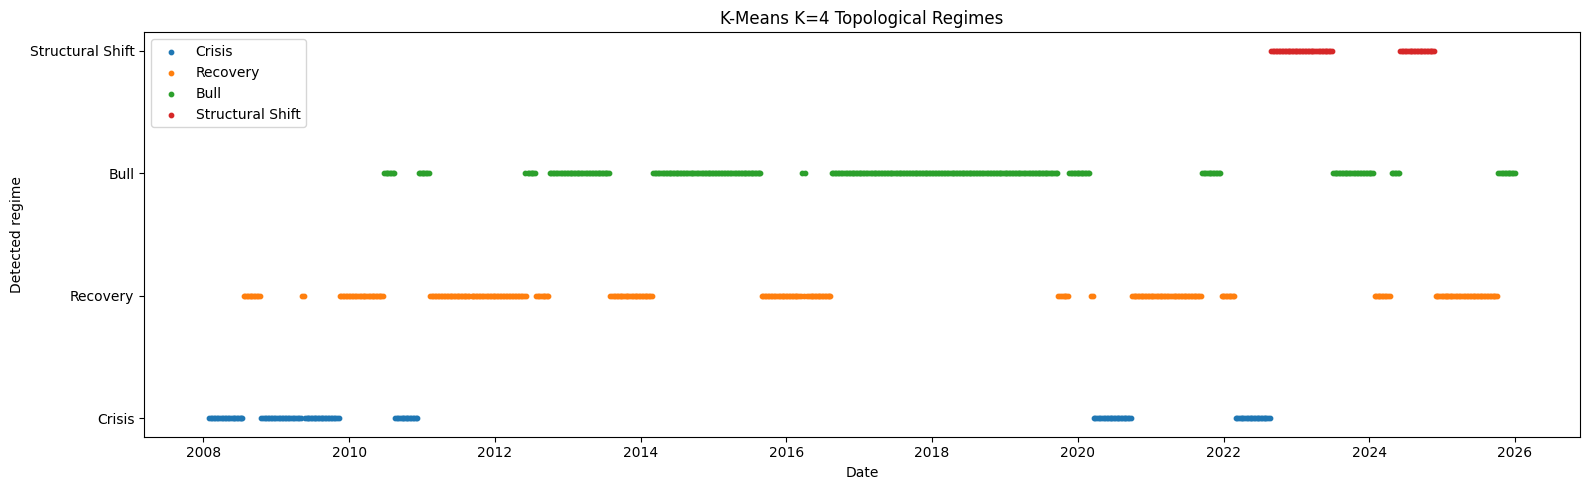

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

LABEL_PATH = "phase3_round2_iterations/kmeans_04/regime_labels.csv"

REGIME_NAMES = {
    0: "Crisis",
    1: "Recovery",
    2: "Bull",
    3: "Structural Shift"
}

df = pd.read_csv(LABEL_PATH, parse_dates=["rebal_date"])
df = df.sort_values("rebal_date")

df["regime_name"] = df["regime"].map(REGIME_NAMES)

fig, ax = plt.subplots(figsize=(16, 5))

for regime, name in REGIME_NAMES.items():
    sub = df[df["regime"] == regime]

    ax.scatter(
        sub["rebal_date"],
        sub["regime"],
        s=10,
        label=name
    )

ax.set_yticks(list(REGIME_NAMES.keys()))
ax.set_yticklabels(list(REGIME_NAMES.values()))
ax.set_xlabel("Date")
ax.set_ylabel("Detected regime")
ax.set_title("K-Means K=4 Topological Regimes")

ax.legend()
plt.tight_layout()

plt.savefig(
    "phase3_round2_iterations/kmeans_04/regime_timeline.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

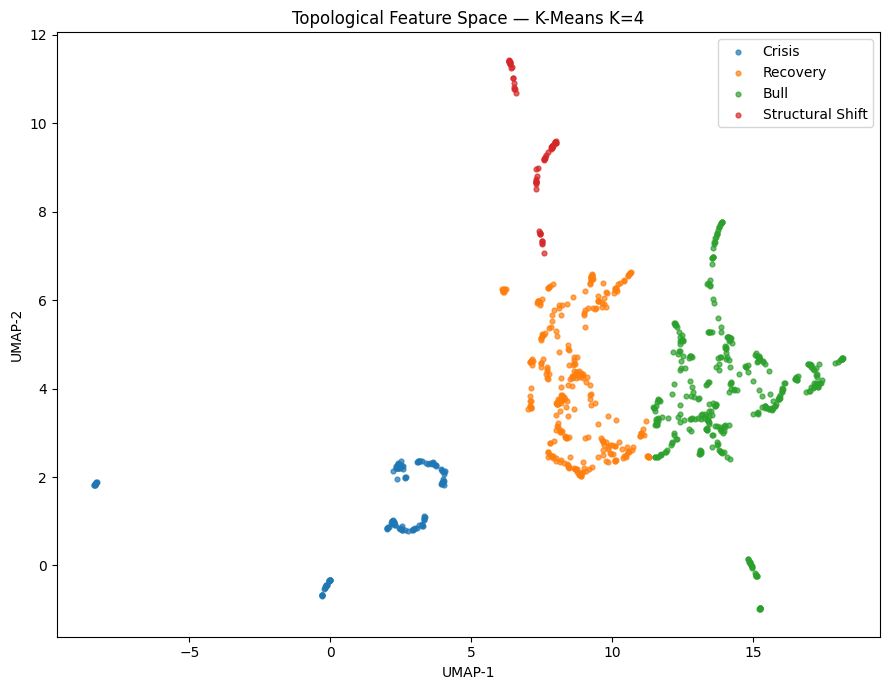

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

LABEL_PATH = "phase3_round2_iterations/kmeans_04/regime_labels.csv"

REGIME_NAMES = {
    0: "Crisis",
    1: "Recovery",
    2: "Bull",
    3: "Structural Shift"
}

df = pd.read_csv(LABEL_PATH)

fig, ax = plt.subplots(figsize=(9, 7))

for regime, name in REGIME_NAMES.items():
    sub = df[df["regime"] == regime]

    ax.scatter(
        sub["umap_x"],
        sub["umap_y"],
        s=12,
        alpha=0.7,
        label=name
    )

ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_title("Topological Feature Space — K-Means K=4")
ax.legend()

plt.tight_layout()

plt.savefig(
    "phase3_round2_iterations/kmeans_04/umap_kmeans4.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

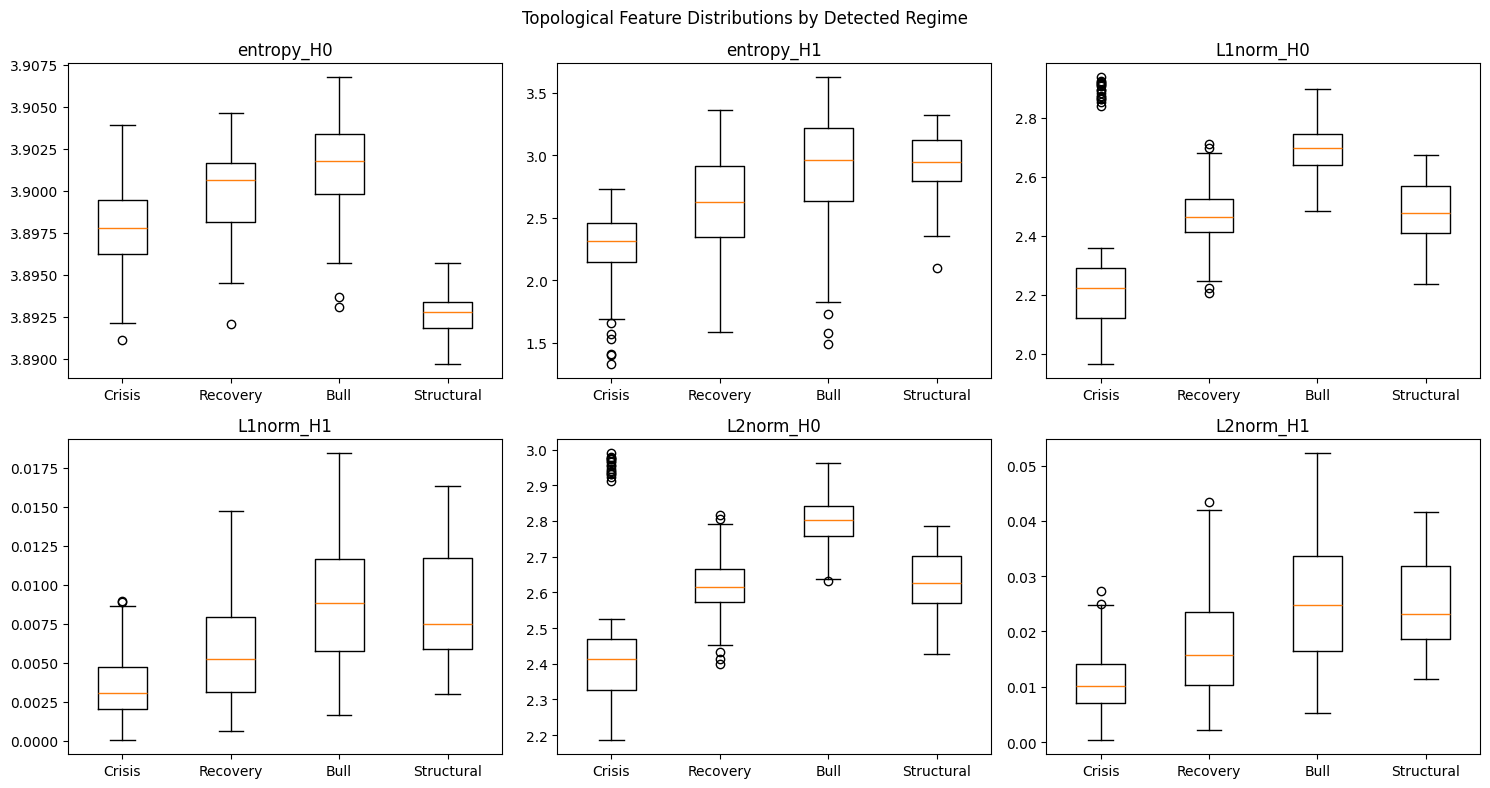

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

FEATURE_PATH = "topo_features.csv"
LABEL_PATH = "phase3_round2_iterations/kmeans_04/regime_labels.csv"

REGIME_NAMES = {
    0: "Crisis",
    1: "Recovery",
    2: "Bull",
    3: "Structural Shift"
}

features = pd.read_csv(FEATURE_PATH, index_col=0, parse_dates=True)
labels = pd.read_csv(LABEL_PATH, parse_dates=["rebal_date"])

labels = labels.set_index("rebal_date")

df = features.join(labels["regime"], how="inner")

cols = [
    "entropy_H0",
    "entropy_H1",
    "L1norm_H0",
    "L1norm_H1",
    "L2norm_H0",
    "L2norm_H1",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flat, cols):

    data = [
        df.loc[df["regime"] == r, col].dropna()
        for r in range(4)
    ]

    ax.boxplot(data)

    ax.set_title(col)
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels(["Crisis", "Recovery", "Bull", "Structural"])

plt.suptitle("Topological Feature Distributions by Detected Regime")
plt.tight_layout()

plt.savefig(
    "phase3_round2_iterations/kmeans_04/topological_regime_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [19]:
import pandas as pd
import numpy as np

LABEL_PATH = "phase3_round2_iterations/kmeans_04/regime_labels.csv"

REGIME_NAMES = {
    0: "Crisis",
    1: "Recovery",
    2: "Bull",
    3: "Structural Shift"
}

df = pd.read_csv(LABEL_PATH, parse_dates=["rebal_date"])
df = df.sort_values("rebal_date").reset_index(drop=True)

# ---------------------------------------------------------
# Correct transition matrix
# ---------------------------------------------------------

current = df["regime"].iloc[:-1].to_numpy()
next_regime = df["regime"].iloc[1:].to_numpy()

transition_counts = pd.crosstab(
    pd.Series(current, name="from"),
    pd.Series(next_regime, name="to")
)

transition_matrix = transition_counts.div(
    transition_counts.sum(axis=1),
    axis=0
)

print("\n=== TRANSITION COUNTS ===")
print(transition_counts)

print("\n=== TRANSITION PROBABILITIES ===")
print(transition_matrix.round(3))

# ---------------------------------------------------------
# Consecutive runs
# ---------------------------------------------------------

df["new_run"] = df["regime"].ne(df["regime"].shift())
df["run_id"] = df["new_run"].cumsum()

runs = (
    df.groupby("run_id")
      .agg(
          regime=("regime", "first"),
          start=("rebal_date", "first"),
          end=("rebal_date", "last"),
          observations=("regime", "size")
      )
      .reset_index(drop=True)
)

runs["regime_name"] = runs["regime"].map(REGIME_NAMES)

runs["calendar_days"] = (
    runs["end"] - runs["start"]
).dt.days

# Approximate trading weeks/months represented by observations
runs["trading_weeks"] = runs["observations"] * 5 / 5
runs["approx_months"] = runs["observations"] * 5 / 21

print("\n=== ALL REGIME RUNS ===")
print(
    runs[
        [
            "regime",
            "regime_name",
            "start",
            "end",
            "observations",
            "calendar_days",
            "approx_months"
        ]
    ].to_string(index=False)
)

# ---------------------------------------------------------
# Duration statistics
# ---------------------------------------------------------

duration_stats = (
    runs.groupby(["regime", "regime_name"])
    .agg(
        number_of_runs=("regime", "size"),
        mean_run_windows=("observations", "mean"),
        median_run_windows=("observations", "median"),
        minimum_run_windows=("observations", "min"),
        maximum_run_windows=("observations", "max"),
        mean_run_days=("calendar_days", "mean"),
        median_run_days=("calendar_days", "median")
    )
)

print("\n=== REGIME DURATION STATISTICS ===")
print(duration_stats.round(2))

# ---------------------------------------------------------
# Very short runs
# ---------------------------------------------------------

short_runs = runs[runs["observations"] <= 3]

print("\n=== RUNS OF 3 OR FEWER WINDOWS ===")
print(
    short_runs[
        [
            "regime",
            "regime_name",
            "start",
            "end",
            "observations"
        ]
    ].to_string(index=False)
)

print("\n=== NUMBER OF SHORT RUNS BY REGIME ===")
print(
    short_runs["regime_name"]
    .value_counts()
    .sort_index()
)

# ---------------------------------------------------------
# Persistence: probability that today's regime remains
# tomorrow
# ---------------------------------------------------------

stay_probability = np.mean(current == next_regime)

print("\n=== OVERALL REGIME PERSISTENCE ===")
print(f"Probability next snapshot has same regime: {stay_probability:.4f}")

print("\n=== PER-REGIME PERSISTENCE ===")

for regime in sorted(df["regime"].unique()):

    mask = current == regime

    if mask.sum() == 0:
        continue

    probability = np.mean(next_regime[mask] == regime)

    print(
        f"{regime} ({REGIME_NAMES[regime]}): "
        f"{probability:.4f}"
    )


=== TRANSITION COUNTS ===
to      0    1    2   3
from                   
0     133    4    1   1
1       4  297   12   0
2       1   11  352   1
3       0    1    1  64

=== TRANSITION PROBABILITIES ===
to        0      1      2      3
from                            
0     0.957  0.029  0.007  0.007
1     0.013  0.949  0.038  0.000
2     0.003  0.030  0.964  0.003
3     0.000  0.015  0.015  0.970

=== ALL REGIME RUNS ===
 regime      regime_name      start        end  observations  calendar_days  approx_months
      0           Crisis 2008-01-31 2008-07-14            23            165       5.476190
      1         Recovery 2008-07-21 2008-10-10            12             81       2.857143
      0           Crisis 2008-10-17 2009-05-04            26            199       6.190476
      1         Recovery 2009-05-11 2009-05-18             2              7       0.476190
      0           Crisis 2009-05-25 2009-11-09            24            168       5.714286
      1         Recovery 2

In [13]:
import shutil
from google.colab import files

# Zip the entire Phase 3 iterations directory
zip_path = shutil.make_archive(
    "phase3_round2_iterations",
    "zip",
    "phase3_round2_iterations"
)

# Download the ZIP
files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#RESULTS OF PHASE 2
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Load Phase 2 outputs
# ---------------------------------------------------------

features = pd.read_csv(
    "topo_features.csv",
    index_col="rebal_date",
    parse_dates=True
)

with open("persistence_diagrams.pkl", "rb") as f:
    persistence_data = pickle.load(f)

dates = persistence_data["dates"]
diagrams = persistence_data["diagrams"]

print("Topological feature matrix:")
print("Shape:", features.shape)

print("\nPersistence diagram dimensions:")
for dim, diag_list in diagrams.items():
    print(f"H{dim}: {len(diag_list)} diagrams")

print("\nDate range:")
print(features.index.min().date(), "to", features.index.max().date())

Topological feature matrix:
Shape: (884, 1216)

Persistence diagram dimensions:
H0: 884 diagrams
H1: 884 diagrams

Date range:
2008-01-31 to 2025-12-31


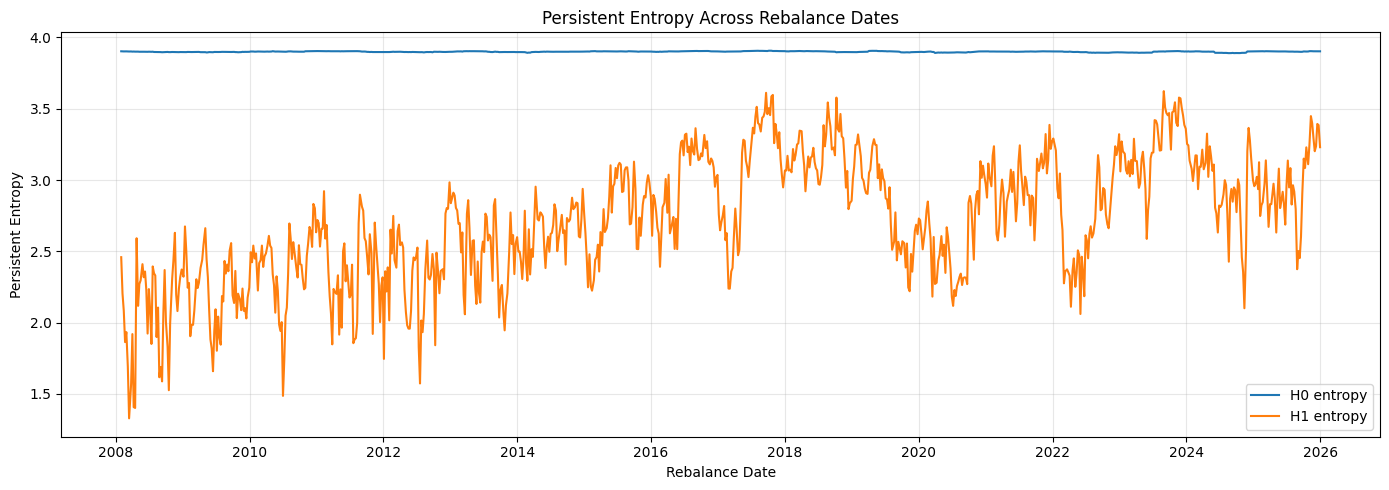

In [ ]:
# ---------------------------------------------------------
# Figure 1: Persistent entropy through time
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    features.index,
    features["entropy_H0"],
    label="H0 entropy",
    linewidth=1.5
)

ax.plot(
    features.index,
    features["entropy_H1"],
    label="H1 entropy",
    linewidth=1.5
)

ax.set_title("Persistent Entropy Across Rebalance Dates")
ax.set_xlabel("Rebalance Date")
ax.set_ylabel("Persistent Entropy")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

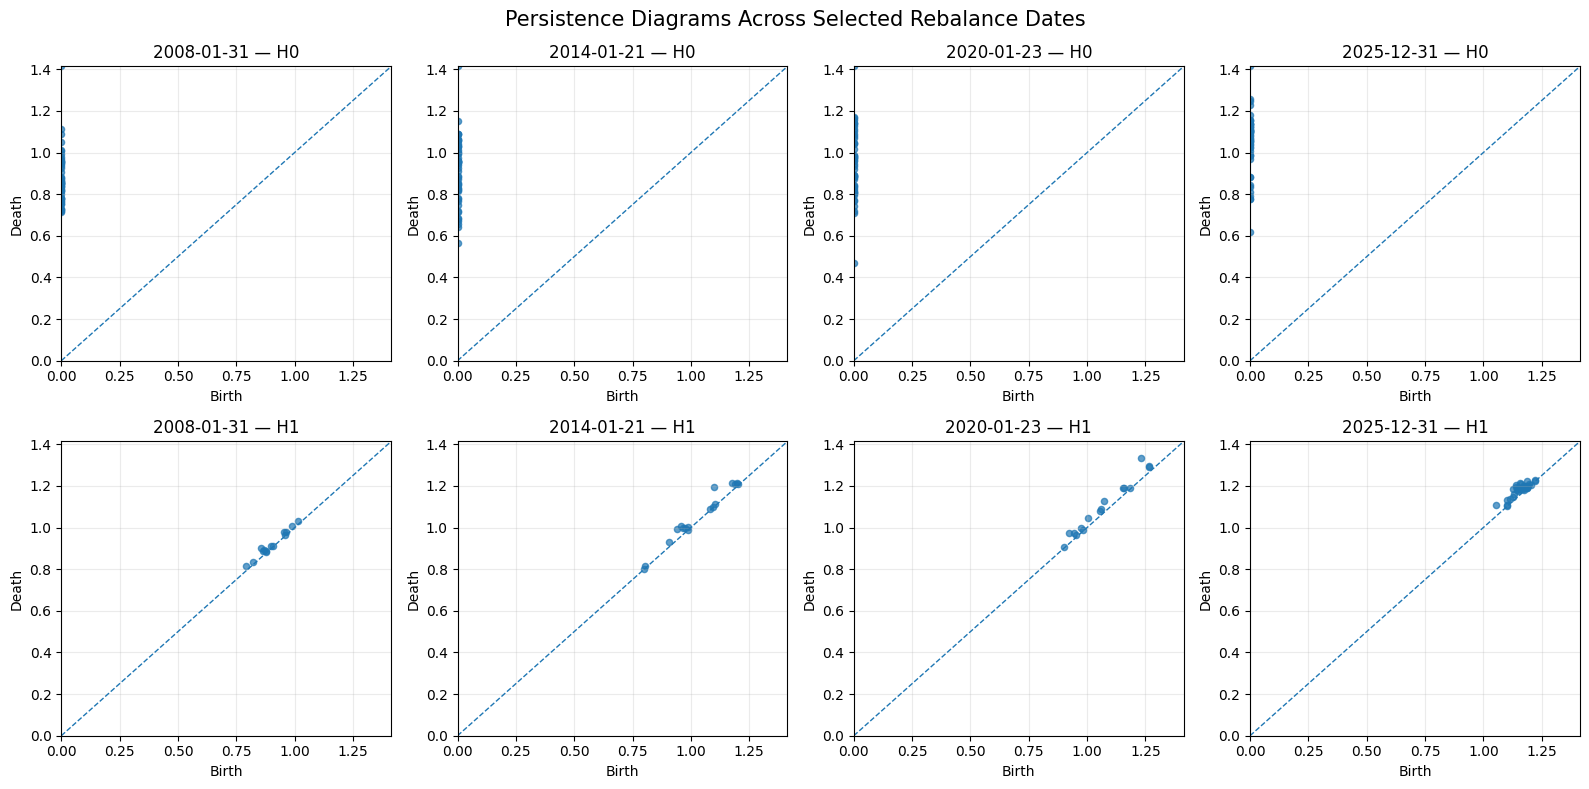

In [ ]:
# ---------------------------------------------------------
# Figure 2: Persistence diagrams
# ---------------------------------------------------------

def plot_persistence_diagram(diagram, title, ax, max_death=np.sqrt(2)):
    diagram = np.asarray(diagram)

    if diagram.size == 0:
        ax.text(
            0.5, 0.5,
            "No persistence points",
            ha="center",
            va="center"
        )
        return

    birth = diagram[:, 0]
    death = diagram[:, 1]

    ax.scatter(
        birth,
        death,
        s=20,
        alpha=0.7
    )

    # Diagonal
    x = np.linspace(0, max_death, 200)
    ax.plot(x, x, linestyle="--", linewidth=1)

    ax.set_xlim(0, max_death)
    ax.set_ylim(0, max_death)

    ax.set_xlabel("Birth")
    ax.set_ylabel("Death")
    ax.set_title(title)
    ax.grid(alpha=0.25)


# Select representative dates
selected_dates = [
    features.index[0],
    features.index[len(features)//3],
    features.index[2*len(features)//3],
    features.index[-1]
]

fig, axes = plt.subplots(
    2, len(selected_dates),
    figsize=(16, 8)
)

for j, date in enumerate(selected_dates):

    for i, dim in enumerate([0, 1]):

        plot_persistence_diagram(
            diagrams[dim][j if False else features.index.get_loc(date)],
            f"{date.date()} — H{dim}",
            axes[i, j]
        )

plt.suptitle(
    "Persistence Diagrams Across Selected Rebalance Dates",
    fontsize=15
)

plt.tight_layout()
plt.show()

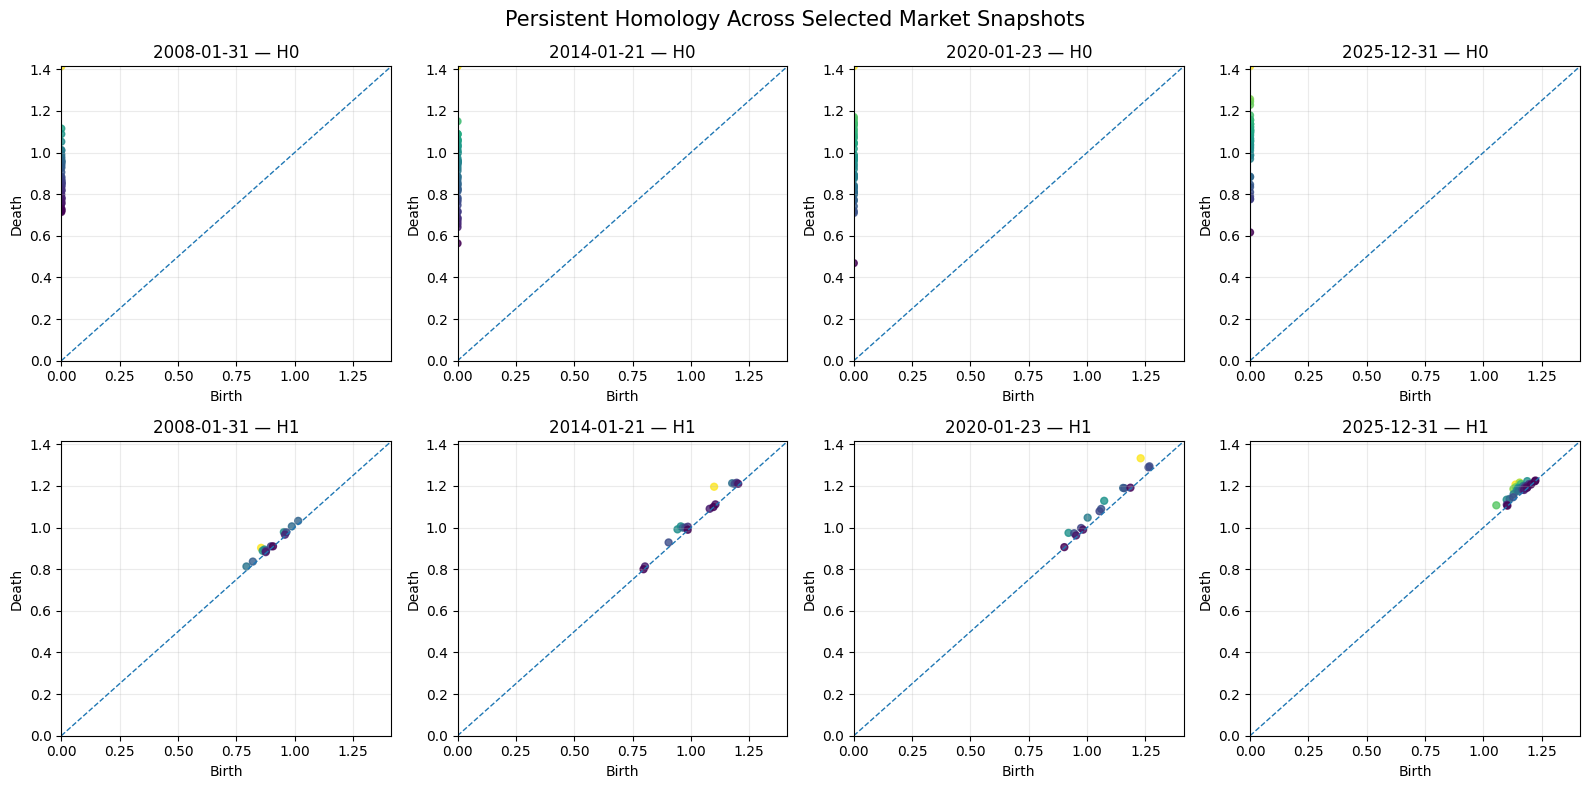

In [ ]:
# ---------------------------------------------------------
# Figure 2B: Persistence diagrams colored by persistence
# ---------------------------------------------------------

def plot_persistence_diagram_colored(diagram, title, ax, max_death=np.sqrt(2)):

    diagram = np.asarray(diagram)

    if diagram.size == 0:
        ax.text(
            0.5, 0.5,
            "No persistence points",
            ha="center",
            va="center"
        )
        return

    birth = diagram[:, 0]
    death = diagram[:, 1]

    persistence = death - birth

    scatter = ax.scatter(
        birth,
        death,
        c=persistence,
        s=25,
        alpha=0.8
    )

    x = np.linspace(0, max_death, 200)
    ax.plot(x, x, linestyle="--", linewidth=1)

    ax.set_xlim(0, max_death)
    ax.set_ylim(0, max_death)

    ax.set_xlabel("Birth")
    ax.set_ylabel("Death")
    ax.set_title(title)

    ax.grid(alpha=0.25)

    return scatter


fig, axes = plt.subplots(
    2,
    len(selected_dates),
    figsize=(16, 8)
)

for j, date in enumerate(selected_dates):

    idx = features.index.get_loc(date)

    for i, dim in enumerate([0, 1]):

        plot_persistence_diagram_colored(
            diagrams[dim][idx],
            f"{date.date()} — H{dim}",
            axes[i, j]
        )

plt.suptitle(
    "Persistent Homology Across Selected Market Snapshots",
    fontsize=15
)

plt.tight_layout()
plt.show()

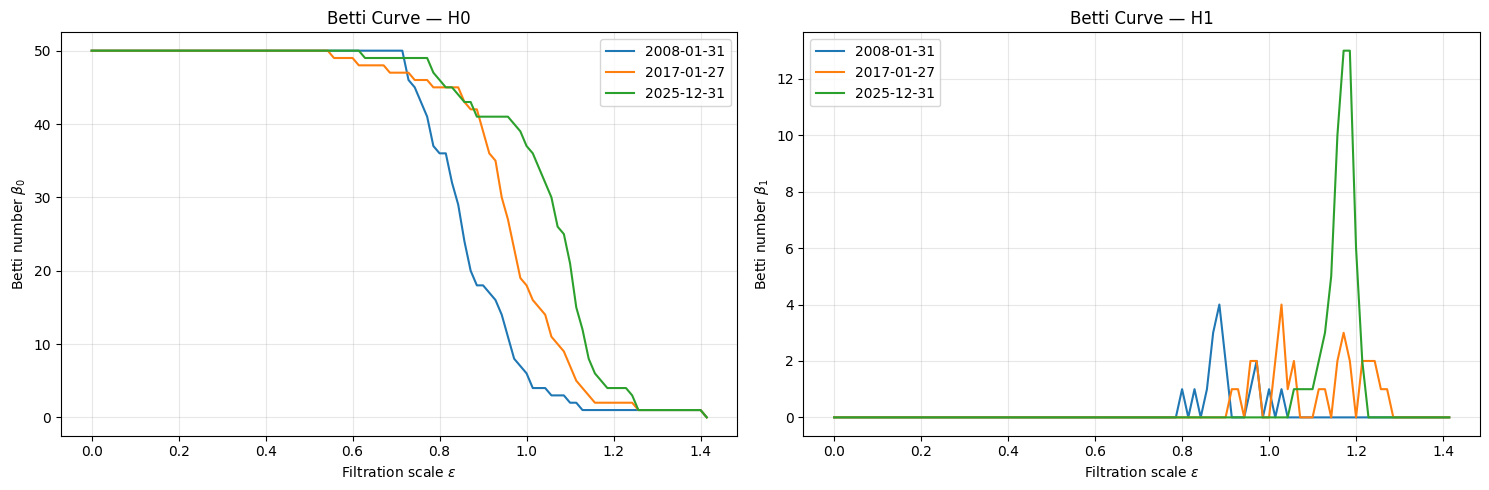

In [ ]:
# ---------------------------------------------------------
# Figure 3: Betti curves
# ---------------------------------------------------------

def get_betti_curve(features, dim, date):
    cols = [
        f"betti_H{dim}_bin{i}"
        for i in range(100)
    ]

    return features.loc[date, cols].values


epsilon = np.linspace(0, np.sqrt(2), 100)

# Choose three dates
selected_betti_dates = [
    features.index[0],
    features.index[len(features)//2],
    features.index[-1]
]

fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 5)
)

for dim, ax in zip([0, 1], axes):

    for date in selected_betti_dates:

        curve = get_betti_curve(
            features,
            dim,
            date
        )

        ax.plot(
            epsilon,
            curve,
            label=str(date.date()),
            linewidth=1.5
        )

    ax.set_title(f"Betti Curve — H{dim}")
    ax.set_xlabel(r"Filtration scale $\epsilon$")
    ax.set_ylabel(r"Betti number $\beta_%d$" % dim)

    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# Figure 4: Persistence landscapes
# ---------------------------------------------------------

epsilon = np.linspace(0, np.sqrt(2), 100)

date = features.index[len(features)//2]

fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 5)
)

for dim, ax in zip([0, 1], axes):

    for layer in range(5):

        cols = [
            f"landscape_H{dim}_layer{layer}_bin{i}"
            for i in range(100)
        ]

        curve = features.loc[date, cols].values

        ax.plot(
            epsilon,
            curve,
            label=f"Layer {layer + 1}"
        )

    ax.set_title(
        f"Persistence Landscape — H{dim}\n{date.date()}"
    )

    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel(r"$\lambda_k(\epsilon)$")

    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

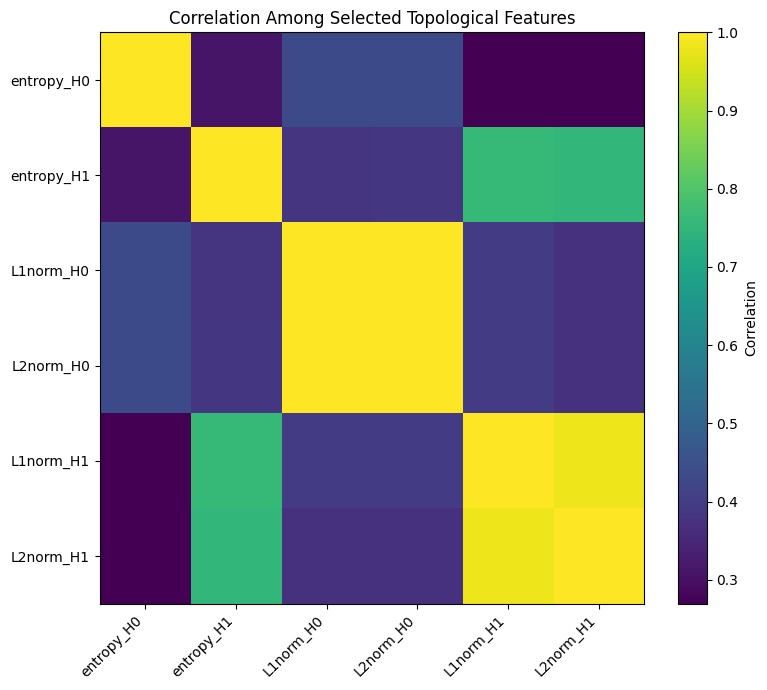

In [ ]:
# ---------------------------------------------------------
# Figure 5: Correlation between topological feature groups
# ---------------------------------------------------------

# Select representative feature columns
selected_cols = [
    "entropy_H0",
    "entropy_H1",
    "L1norm_H0",
    "L2norm_H0",
    "L1norm_H1",
    "L2norm_H1",
]

corr = features[selected_cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(corr.values, aspect="auto")

ax.set_xticks(range(len(selected_cols)))
ax.set_yticks(range(len(selected_cols)))

ax.set_xticklabels(selected_cols, rotation=45, ha="right")
ax.set_yticklabels(selected_cols)

ax.set_title("Correlation Among Selected Topological Features")

plt.colorbar(im, ax=ax, label="Correlation")

plt.tight_layout()
plt.show()

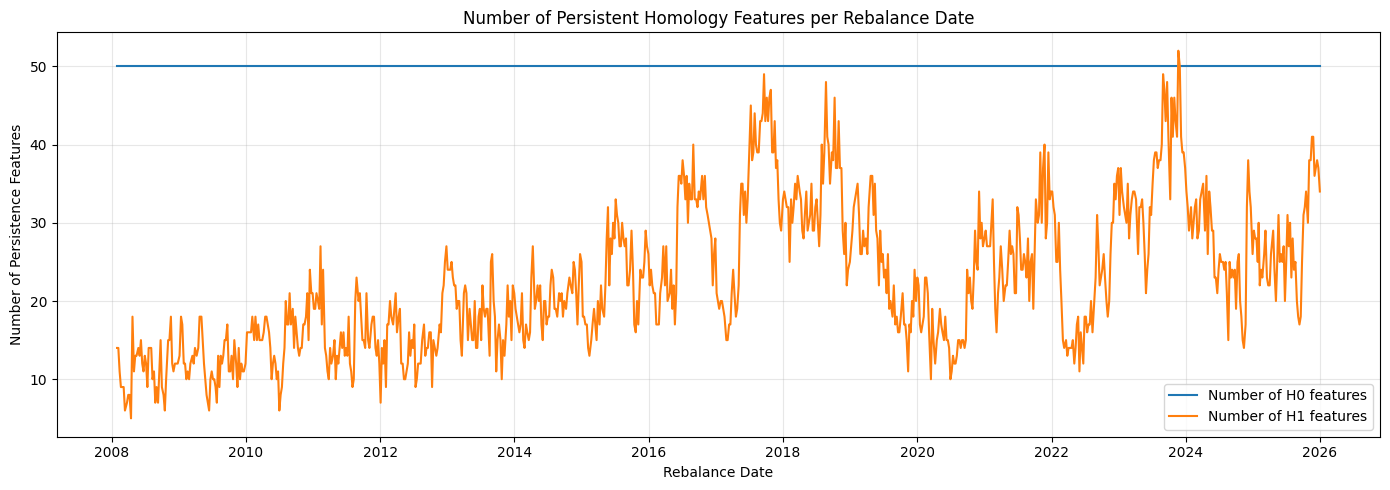

In [ ]:
# ---------------------------------------------------------
# Figure 6: Number of H1 persistence features over time
# ---------------------------------------------------------

h0_counts = [
    len(diagrams[0][i])
    for i in range(len(dates))
]

h1_counts = [
    len(diagrams[1][i])
    for i in range(len(dates))
]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    features.index,
    h0_counts,
    label="Number of H0 features",
    linewidth=1.5
)

ax.plot(
    features.index,
    h1_counts,
    label="Number of H1 features",
    linewidth=1.5
)

ax.set_title("Number of Persistent Homology Features per Rebalance Date")
ax.set_xlabel("Rebalance Date")
ax.set_ylabel("Number of Persistence Features")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [1]:
import os
os.makedirs("data")

In [ ]:
!pip install -U gudhi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 12.9 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("data")

duplicates = {}

for path in sorted(DATA_DIR.glob("*.csv")):
    df = pd.read_csv(path)
    df.columns = [c.lower().strip() for c in df.columns]

    date_col = next(c for c in df.columns if "date" in c)

    dates = pd.to_datetime(df[date_col], errors="coerce")

    dup = dates[dates.duplicated(keep=False)]

    if len(dup) > 0:
        duplicates[path.stem] = dup

print(f"Tickers with duplicate dates: {len(duplicates)}")

for ticker, dates in duplicates.items():
    print(f"\n{ticker}: {len(dates)} duplicate-date rows")
    print(sorted(dates.unique())[:10])

Tickers with duplicate dates: 1

TATAMOTORS: 40 duplicate-date rows
[Timestamp('2010-10-18 00:00:00'), Timestamp('2011-05-06 00:00:00'), Timestamp('2011-08-09 00:00:00'), Timestamp('2011-09-19 00:00:00'), Timestamp('2011-10-24 00:00:00'), Timestamp('2012-03-03 00:00:00'), Timestamp('2013-04-26 00:00:00'), Timestamp('2021-05-21 00:00:00'), Timestamp('2021-10-04 00:00:00'), Timestamp('2022-07-25 00:00:00')]


In [ ]:
import pandas as pd

df = pd.read_csv("data/TATAMOTORS.csv")
df.columns = [c.lower().strip() for c in df.columns]

df["date"] = pd.to_datetime(df["date"], errors="coerce")

print(
    df[df["date"] == pd.Timestamp("2009-06-25")]
)

          date  close
609 2009-06-25  337.3
610 2009-06-25  363.0


In [ ]:
df = pd.read_csv("data/TATAMOTORS.csv")
df.columns = [c.lower().strip() for c in df.columns]
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print(
    df[
        (df["date"] >= "2009-06-23") &
        (df["date"] <= "2009-06-29")
    ].to_string(index=False)
)

      date  close
2009-06-23 342.40
2009-06-24 357.25
2009-06-25 337.30
2009-06-25 363.00
2009-06-26 340.25
2009-06-29 313.90


In [4]:
import pandas as pd

path = "data/TATAMOTORS.csv"

df = pd.read_csv(path)

# Normalize column names
df.columns = [c.lower().strip() for c in df.columns]

# Convert date
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Remove the incorrect duplicate for 2009-06-25
mask = (
    (df["date"] == pd.Timestamp("2009-06-25")) &
    (df["close"] == 363.0)
)

df = df.loc[~mask].copy()

# Sort and save
df = df.sort_values("date")
df.to_csv(path, index=False)

print("Fixed TATAMOTORS.csv")
print(df[df["date"] == "2009-06-25"])

Fixed TATAMOTORS.csv
          date  close
609 2009-06-25  337.3


In [ ]:
import pandas as pd

df = pd.read_csv("data/TATAMOTORS.csv")
df.columns = [c.lower().strip() for c in df.columns]
df["date"] = pd.to_datetime(df["date"])

dups = df[df["date"].duplicated(keep=False)].sort_values("date")

print(dups.to_string(index=False))

      date   close
2010-10-18 1168.95
2010-10-18 1146.00
2011-05-06 1199.95
2011-05-06 1199.95
2011-08-09  794.05
2011-08-09  794.05
2011-09-19  161.70
2011-09-19  159.00
2011-10-24  186.15
2011-10-24  186.15
2012-03-03  267.65
2012-03-03  267.95
2013-04-26  292.00
2013-04-26  296.30
2021-05-21  313.10
2021-05-21  313.40
2021-10-04  342.00
2021-10-04  333.30
2022-07-25  449.55
2022-07-25  454.90
2022-08-08  465.25
2022-08-08  468.25
2022-10-03  397.65
2022-10-03  404.60
2022-10-17  396.25
2022-10-17  396.10
2022-10-25  404.55
2022-10-25  401.60
2022-11-03  422.15
2022-11-03  416.25
2022-11-14  423.50
2022-11-14  433.70
2024-03-07 1039.30
2024-03-07 1017.65
2025-07-14  681.80
2025-07-14  674.50
2025-09-09  719.50
2025-09-09  715.55
2025-10-09  681.55
2025-10-09  681.10


In [5]:
import pandas as pd

path = "data/TATAMOTORS.csv"

df = pd.read_csv(path)

df.columns = [c.lower().strip() for c in df.columns]
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["close"] = pd.to_numeric(df["close"], errors="coerce")

# Verified NSE values
nse_values = {
    "2009-06-25": 337.30,
    "2010-10-18": 1146.00,
    "2011-05-06": 1199.95,
    "2011-08-09": 794.05,
    "2011-09-19": 159.00,
    "2011-10-24": 186.15,
    "2012-03-03": 267.65,
    "2013-04-26": 292.00,
    "2021-05-21": 313.10,
    "2021-10-04": 333.30,
    "2022-07-25": 454.90,
    "2022-08-08": 465.25,
    "2022-10-03": 404.60,
    "2022-10-17": 396.25,
    "2022-10-25": 401.60,
    "2022-11-03": 422.15,
    "2022-11-14": 423.50,
    "2024-03-07": 1017.65,
    "2025-07-14": 681.80,
    "2025-09-09": 715.55,
    "2025-10-09": 681.10,
}

# For every affected date:
# retain the row matching the verified NSE close.
for date_str, correct_close in nse_values.items():
    date = pd.Timestamp(date_str)

    mask = df["date"] == date

    if mask.sum() == 0:
        print(f"WARNING: {date_str} not found")
        continue

    df.loc[mask, "close"] = correct_close

    # If multiple rows exist, keep only the first
    # now that its close has been normalized to the verified NSE value.
    first_idx = df.index[mask][0]
    df = df.drop(index=df.index[mask & (df.index != first_idx)])

df = df.sort_values("date")

df.to_csv(path, index=False)

print("TATAMOTORS NSE corrections applied.")
print("Rows:", len(df))
print("Duplicate dates:", df["date"].duplicated().sum())

TATAMOTORS NSE corrections applied.
Rows: 4708
Duplicate dates: 0
